# **Exoplanet Demographics: un pipeline end‑to‑end con datos del NASA Exoplanet Archive**

---

**Autor:** Juan Diego Rodríguez \
**Profesor:** José Ivan Campos Rozo \
**Asignatura:** Astrofísica Computacional \
**Observatorio Astronómico Nacional** \
**Semestre 2026-1**

### **Contexto científico**

Desde el descubrimiento de 51 Pegasi b en 1995 (Mayor & Queloz 1995), la exoplanetología ha experimentado un crecimiento explosivo. En la actualidad, el **NASA Exoplanet Archive** alberga más de 5000 planetas confirmados, con parámetros físicos que abarcan desde Súper‑Tierras hasta gigantes gaseosos. 

Este proyecto se enmarca en la **Opción D** de la asignatura *Astrofísica Computacional*, y tiene como objetivo construir una **pipeline completa de datos astronómicos** que reproduzca el flujo de trabajo profesional en la investigación astrofísica actual.

### **Objetivos del pipeline**

La pipeline consta de cinco etapas secuenciales:

1. **Adquisición de datos** – Consulta programática al NASA Exoplanet Archive (TAP) para obtener una muestra de planetas confirmados con parámetros clave (radio, masa, temperatura de equilibrio, método de detección, año de descubrimiento, tipo espectral de la estrella).
2. **Diseño e ingesta en SQLite** – Creación de una base de datos relacional normalizada con índices para consultas eficientes, y almacenamiento de los datos descargados.
3. **Análisis estadístico con SQL** – Extracción de estadísticas agregadas (medias, medianas, conteos) mediante consultas SQL parametrizadas, integradas con Pandas.
4. **Visualización y dashboard** – Generación de gráficos de calidad publicación (histogramas, diagramas de dispersión, boxplots, curvas de tendencia, líneas de tiempo acumuladas) que exploran las relaciones entre parámetros y la evolución histórica de los descubrimientos.
5. **Interpretación física y redacción** – Análisis de los resultados a la luz de la literatura, discusión de sesgos y limitaciones, y elaboración de un informe estructurado (integrado en el propio notebook).

### **Datos y muestra**

La consulta al **NASA Exoplanet Archive** (tabla `pscomppars`) selecciona planetas confirmados (`pl_controv_flag = 0`) que poseen valores no nulos de:
- **Radio** (`pl_rade`, en radios terrestres)
- **Masa** (`pl_bmasse`, en masas terrestres)
- **Temperatura de equilibrio** (`pl_eqt`, en Kelvin)

Además, se añade una clasificación en **zonas térmicas**:
- **Frías** (T < 273 K)
- **Templadas** (273 K ≤ T < 373 K)
- **Calientes** (T ≥ 373 K)

La muestra final contiene **5 679 planetas** (según los datos descargados en la ejecución de este notebook), lo que proporciona una base estadística sólida para el análisis.

### **Metodología y herramientas**

El notebook está desarrollado íntegramente en Python y hace uso de las siguientes librerías:

| Librería | Propósito |
|----------|-----------|
| `astroquery` / `requests` | Consulta al servicio TAP del Exoplanet Archive |
| `sqlite3` | Creación y gestión de la base de datos local |
| `pandas` | Manipulación y análisis de datos |
| `numpy` / `scipy` | Cálculos numéricos y ajustes (ley de potencias, distribuciones) |
| `matplotlib` / `seaborn` | Visualización científica de alta calidad |

El código está estructurado en celdas etiquetadas por etapas, con comentarios y bloques de texto explicativos que facilitan la reproducibilidad y la comprensión del flujo de trabajo.

### **Referencias iniciales**

- Akeson, R. L., et al. (2013). *The NASA Exoplanet Archive: Data and Tools*. PASP, 125, 989.
- Chen, J., & Kipping, D. (2017). *Probabilistic Forecasting of the Masses and Radii of Other Worlds*. ApJ, 834(1), 17.
- Fulton, B. J., & Petigura, E. A. (2018). *The California‑Kepler Survey. VII. Precise Radii of 869 Kepler Planets*. AJ, 156, 264.
- Mayor, M., & Queloz, D. (1995). *A Jupiter‑mass companion to a solar‑type star*. Nature, 378, 355.

## **Etapa 1 - Adquisición de Datos desde el NASA Exoplanet Archive**

In [21]:
import requests
import io
import pandas as pd

url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
query = "SELECT column_name, description FROM TAP_SCHEMA.columns WHERE table_name = 'pscomppars'"
params = {"query": query, "format": "csv"}
response = requests.get(url, params=params)
df_cols = pd.read_csv(io.StringIO(response.text))
print(df_cols)

        column_name                                   description
0           st_nrvc         Number of Radial Velocity Time Series
1          st_nspec        Number of Stellar Spectra Measurements
2         pl_nnotes                               Number of Notes
3      pl_ntranspec                Number of Transmission Spectra
4         pl_nespec                     Number of Eclipse Spectra
..              ...                                           ...
394      pl_esmerr2                  Emission Spectroscopy Metric
395  pl_esm_reflink                  Emission Spectroscopy Metric
396   pl_esm_solnid                  Emission Spectroscopy Metric
397       pl_esmstr  Emission Spectroscopy Metric Symmetric Error
398       pl_esmlim            Emission Spectroscopy Metric Limit

[399 rows x 2 columns]


In [22]:
# Buscar columnas relacionadas con temperatura
print("=== Columnas de temperatura ===")
temp_cols = df_cols[df_cols['column_name'].str.contains('temp|eq|equilibrium', case=False, na=False)]
print(temp_cols)

# Buscar columnas de tipo espectral
print("\n=== Columnas de tipo espectral ===")
spec_cols = df_cols[df_cols['column_name'].str.contains('spectype|sptype|st_', case=False, na=False)]
print(spec_cols)

# Buscar columnas de semieje mayor
print("\n=== Columnas de semieje mayor ===")
smax_cols = df_cols[df_cols['column_name'].str.contains('smax|orb|axis', case=False, na=False)]
print(smax_cols)

=== Columnas de temperatura ===
        column_name                         description
189          pl_eqt             Equilibrium Temperature
190      pl_eqterr1  Equilibrium Temperature Upper Unc.
191      pl_eqterr2  Equilibrium Temperature Lower Unc.
192       pl_eqtlim  Equilibrium Temperature Limit Flag
193       pl_eqtstr             Equilibrium Temperature
194  pl_eqt_reflink   Equilibrium Temperature Reference

=== Columnas de tipo espectral ===
           column_name                                   description
0              st_nrvc         Number of Radial Velocity Time Series
1             st_nspec        Number of Stellar Spectra Measurements
27     sy_dist_reflink                              Distance Refence
112        st_metratio                     Stellar Metallicity Ratio
113        st_spectype                                 Spectral Type
..                 ...                                           ...
378           st_nphot              Number of Photometry 

In [23]:
import numpy as np
import pandas as pd
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive as NEA

print("⏳ Ejecutando consulta al NASA Exoplanet Archive...")

try:
    table = NEA.query_criteria(
        table="pscomppars",  # Tabla correcta según TAP_SCHEMA
        select="pl_name, pl_orbper, pl_orbsmax, pl_rade, pl_bmasse, pl_eqt, st_spectype, discoverymethod, disc_year",
        where="pl_controv_flag=0 AND pl_rade IS NOT NULL AND pl_bmasse IS NOT NULL AND pl_eqt IS NOT NULL"
    )
    df_raw = table.to_pandas()
    print(f"✅ Se descargaron {len(df_raw)} planetas con todos los parámetros requeridos.")

    # Añadir zona térmica (usando pl_eqt)
    conditions = [df_raw['pl_eqt'] < 273, df_raw['pl_eqt'] < 373]
    choices = ['Cold', 'Temperate']
    df_raw['temp_zone'] = np.select(conditions, choices, default='Hot')

    print("\nDistribución por zona térmica:")
    print(df_raw['temp_zone'].value_counts())
    display(df_raw.head())

except Exception as e:
    print(f"❌ Error en la descarga: {e}")
    raise  

⏳ Ejecutando consulta al NASA Exoplanet Archive...
✅ Se descargaron 5694 planetas con todos los parámetros requeridos.

Distribución por zona térmica:
temp_zone
Hot          4821
Cold          515
Temperate     358
Name: count, dtype: int64


,pl_name,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_eqt,st_spectype,discoverymethod,disc_year,temp_zone
0,Kepler-1597 b,2.946542,0.04136,1.06,1.20,1497.0,,Transit,2016,Hot
1,Kepler-687 b,20.505870,0.13260,3.52,12.20,518.0,,Transit,2016,Hot
2,Kepler-1596 b,66.373379,0.32370,1.90,4.27,471.0,,Transit,2016,Hot
3,Kepler-692 b,21.812935,0.14950,3.11,9.85,639.0,,Transit,2016,Hot
4,Kepler-150 c,7.381998,0.07300,3.69,13.20,876.0,,Transit,2014,Hot



## **Etapa 2 – Arquitectura e integración de datos en SQLite**

In [24]:
db_path = 'exoplanets.db'
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

cursor.execute('DROP TABLE IF EXISTS exoplanets')
cursor.execute('DROP TABLE IF EXISTS metadata')

cursor.execute('''
CREATE TABLE exoplanets (
    pl_name TEXT PRIMARY KEY,
    pl_orbper REAL,
    pl_orbsmax REAL,
    pl_rade REAL,
    pl_bmasse REAL,
    pl_eqt REAL,
    st_spectype TEXT,
    discoverymethod TEXT,
    disc_year INTEGER,
    temp_zone TEXT
)
''')

cursor.execute('CREATE INDEX idx_method ON exoplanets(discoverymethod)')

# Ingesta de datos
df_raw.to_sql('exoplanets', conn, if_exists='append', index=False)

cursor.execute('''
CREATE TABLE metadata (
    key TEXT PRIMARY KEY,
    value TEXT
)
''')
cursor.execute('INSERT INTO metadata (key, value) VALUES (?, ?)', ('query_date', pd.Timestamp.now().isoformat()))
cursor.execute('INSERT INTO metadata (key, value) VALUES (?, ?)', ('num_records', str(len(df_raw))))

conn.commit()
print("✅ Base de datos creada y poblada.")
conn.close()

✅ Base de datos creada y poblada.


## **Etapa 3 – Consultas SQL y Análisis Estadístico**

In [25]:
conn = sqlite3.connect(db_path)

# 1. Estadísticas por método
query_stats = """
SELECT 
    discoverymethod,
    COUNT(*) AS n_planets,
    AVG(pl_rade) AS avg_radius_earth,
    AVG(pl_bmasse) AS avg_mass_earth,
    AVG(pl_eqt) AS avg_temp_K,
    MIN(pl_rade) AS min_radius,
    MAX(pl_rade) AS max_radius
FROM exoplanets
GROUP BY discoverymethod
ORDER BY n_planets DESC
"""
df_stats = pd.read_sql(query_stats, conn)
print("📊 Estadísticas por método de descubrimiento:")
display(df_stats)

# 2. Filtro: planetas con radio > 2 R⊕
query_filter = """
SELECT pl_name, pl_rade, pl_bmasse, pl_orbper, discoverymethod, temp_zone, st_spectype
FROM exoplanets
WHERE pl_rade > 2.0
"""
df_filtered = pd.read_sql(query_filter, conn)
print(f"\n🔍 Planetas con radio > 2 R⊕: {len(df_filtered)}")

# 3. Consulta parametrizada (temperatura < 300 K)
threshold_temp = 300
query_param = """
SELECT pl_name, pl_eqt, temp_zone
FROM exoplanets
WHERE pl_eqt < ?
"""
df_param = pd.read_sql(query_param, conn, params=(threshold_temp,))
print(f"\n🌡️ Planetas con T < {threshold_temp} K: {len(df_param)}")

# 4. Agregación por zona térmica
query_zone = """
SELECT 
    temp_zone,
    COUNT(*) AS count,
    AVG(pl_rade) AS mean_radius,
    AVG(pl_bmasse) AS mean_mass,
    AVG(pl_eqt) AS mean_temp
FROM exoplanets
GROUP BY temp_zone
ORDER BY mean_temp
"""
df_zone = pd.read_sql(query_zone, conn)
print("\n📌 Estadísticas por zona térmica:")
display(df_zone)

conn.close()

📊 Estadísticas por método de descubrimiento:


,discoverymethod,n_planets,avg_radius_earth,avg_mass_earth,avg_temp_K,min_radius,max_radius
0,Transit,4470,4.388287,127.774865,919.930145,0.30980,25.00000
1,Radial Velocity,1091,9.924057,1010.419851,476.623428,0.63700,15.58051
2,Imaging,85,15.088501,4344.564143,1170.614235,10.46800,87.20587
3,Transit Timing Variations,33,6.288455,563.911513,575.827576,0.37000,14.10000
4,Microlensing,6,9.755000,347.134715,104.105000,2.21000,14.00000
5,Astrometry,3,12.766667,2866.812231,157.096667,12.10000,13.30000
6,Eclipse Timing Variations,3,13.000000,1395.454909,369.706667,12.70000,13.40000
7,Disk Kinematics,1,13.300000,794.575000,63.440000,13.30000,13.30000
8,Orbital Brightness Modulation,1,15.244240,638.838300,2140.000000,15.24424,15.24424
9,Pulsation Timing Variations,1,13.100000,1017.056000,519.690000,13.10000,13.10000



🔍 Planetas con radio > 2 R⊕: 4004

🌡️ Planetas con T < 300 K: 599

📌 Estadísticas por zona térmica:


,temp_zone,count,mean_radius,mean_mass,mean_temp
0,Cold,515,10.875232,1510.698535,166.712835
1,Temperate,358,5.741328,357.265362,326.491788
2,Hot,4821,5.072426,243.274854,944.363292


## **Etapa 4 – Visualizaciones Estadísticas**



In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 14         
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

# Cargar datos desde la base de datos
conn = sqlite3.connect('exoplanets.db')
df_all = pd.read_sql("SELECT * FROM exoplanets", conn)
conn.close()

### **Gráficas estadísticas**


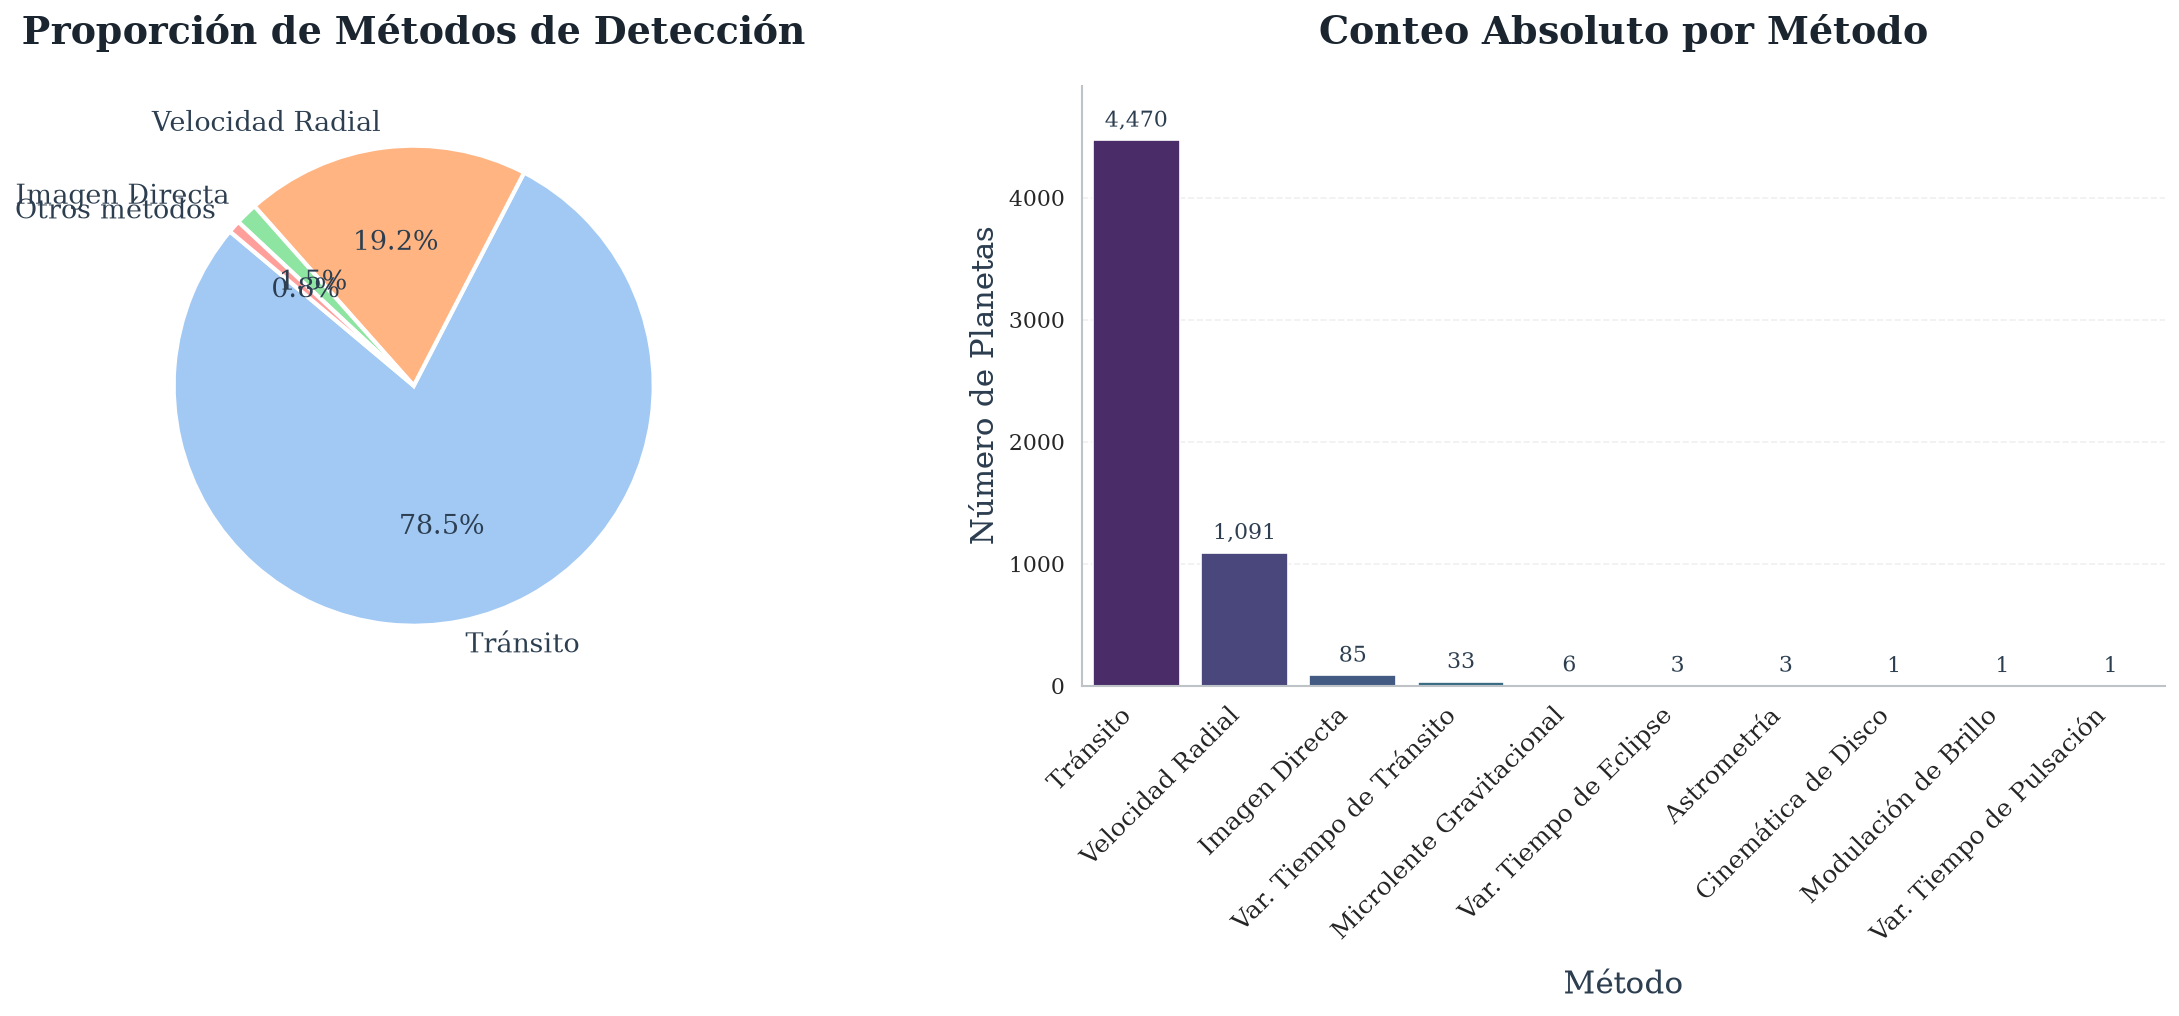

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Preparación y traducción de datos
method_counts = df_all['discoverymethod'].value_counts()

nombres_metodos = {
    'Transit': 'Tránsito',
    'Radial Velocity': 'Velocidad Radial',
    'Imaging': 'Imagen Directa',
    'Transit Timing Variations': 'Var. Tiempo de Tránsito',
    'Microlensing': 'Microlente Gravitacional',
    'Astrometry': 'Astrometría',
    'Eclipse Timing Variations': 'Var. Tiempo de Eclipse',
    'Orbital Brightness Modulation': 'Modulación de Brillo',
    'Disk Kinematics': 'Cinemática de Disco',
    'Pulsation Timing Variations': 'Var. Tiempo de Pulsación'
}
method_counts.index = method_counts.index.map(lambda x: nombres_metodos.get(x, x))

# Lógica para el Pie Chart
umbral = 1.0 # Porcentaje mínimo para mostrarse individualmente (1%)
total_planetas = method_counts.sum()
porcentajes = (method_counts / total_planetas) * 100

# Separar principales de secundarios
metodos_principales = method_counts[porcentajes >= umbral].copy()
otros_metodos_sum = method_counts[porcentajes < umbral].sum()

if otros_metodos_sum > 0:
    metodos_principales['Otros métodos'] = otros_metodos_sum

# Paleta de colores suave y profesional para el pie
colors_pie = sns.color_palette('pastel', len(metodos_principales))

# Gráfico Pie Chart 
wedges, texts, autotexts = ax1.pie(
    metodos_principales, 
    labels=metodos_principales.index, 
    autopct='%1.1f%%', 
    startangle=140, # Girar para que "Otros métodos" quede bien posicionado
    colors=colors_pie,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}, # Líneas blancas de separación
    textprops={'fontsize': 13, 'color': '#2c3e50'}
)
ax1.set_title('Proporción de Métodos de Detección', fontweight='bold', fontsize=18, color='#1a252f', pad=20)

# Gráfico Barras
# Usamos los datos completos aquí para no perder la granularidad de cuántos hay en los métodos pequeños
bar_palette = sns.color_palette('viridis', len(method_counts))
bars = sns.barplot(x=method_counts.index, y=method_counts.values, ax=ax2, palette=bar_palette)

ax2.set_xlabel('Método', fontsize=15, color='#2c3e50', labelpad=10)
ax2.set_ylabel('Número de Planetas', fontsize=15, color='#2c3e50')
ax2.set_title('Conteo Absoluto por Método', fontweight='bold', fontsize=18, color='#1a252f', pad=20)

# Rotación y alineación a la derecha
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=12)

# Añadir el valor numérico encima de cada barra
for p in ax2.patches:
    ax2.annotate(f"{int(p.get_height()):,}", 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='bottom', 
                 fontsize=10.5, color='#2c3e50',
                 xytext=(0, 4), textcoords='offset points')

# Estética del gráfico de barras
ax2.grid(axis='y', linestyle='--', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#bdc3c7')
ax2.spines['bottom'].set_color('#bdc3c7')

# Extender el límite Y ligeramente para que los números encima de las barras no se corten
ax2.set_ylim(0, method_counts.max() * 1.1)

plt.tight_layout()
plt.savefig('fig1_methods.png', dpi=300, bbox_inches='tight')
plt.savefig('fig1_methods.pdf', bbox_inches='tight')
plt.show()

### **Proporción y Conteo Absoluto de Métodos de Detección**

Esta figura expone el sesgo observacional inherente a la exoplanetología moderna. 

*   **Método de tránsito:** Domina abrumadoramente el catálogo con un **78.5%** de las detecciones (más de 4,400 exoplanetas). Esto no significa que la mayoría de los planetas en el universo transiten sus estrellas, sino que misiones espaciales como *Kepler* y *TESS* han sido extremadamente eficientes escaneando miles de estrellas simultáneamente en busca de caídas fotométricas.

*   **Velocidad radial:** Responsable del **19.2%** de los descubrimientos, sigue siendo el segundo método más prolífico y es fundamental para obtener la masa dinámica de los planetas descubiertos por tránsito. 

*   **Otros métodos:** (Imagen directa, microlente, etc.) Representan una fracción de la población total extremadamente pequeña, reflejando las severas limitaciones tecnológicas actuales para resolver objetos tan tenues y cercanos a sus estrellas anfitrionas.



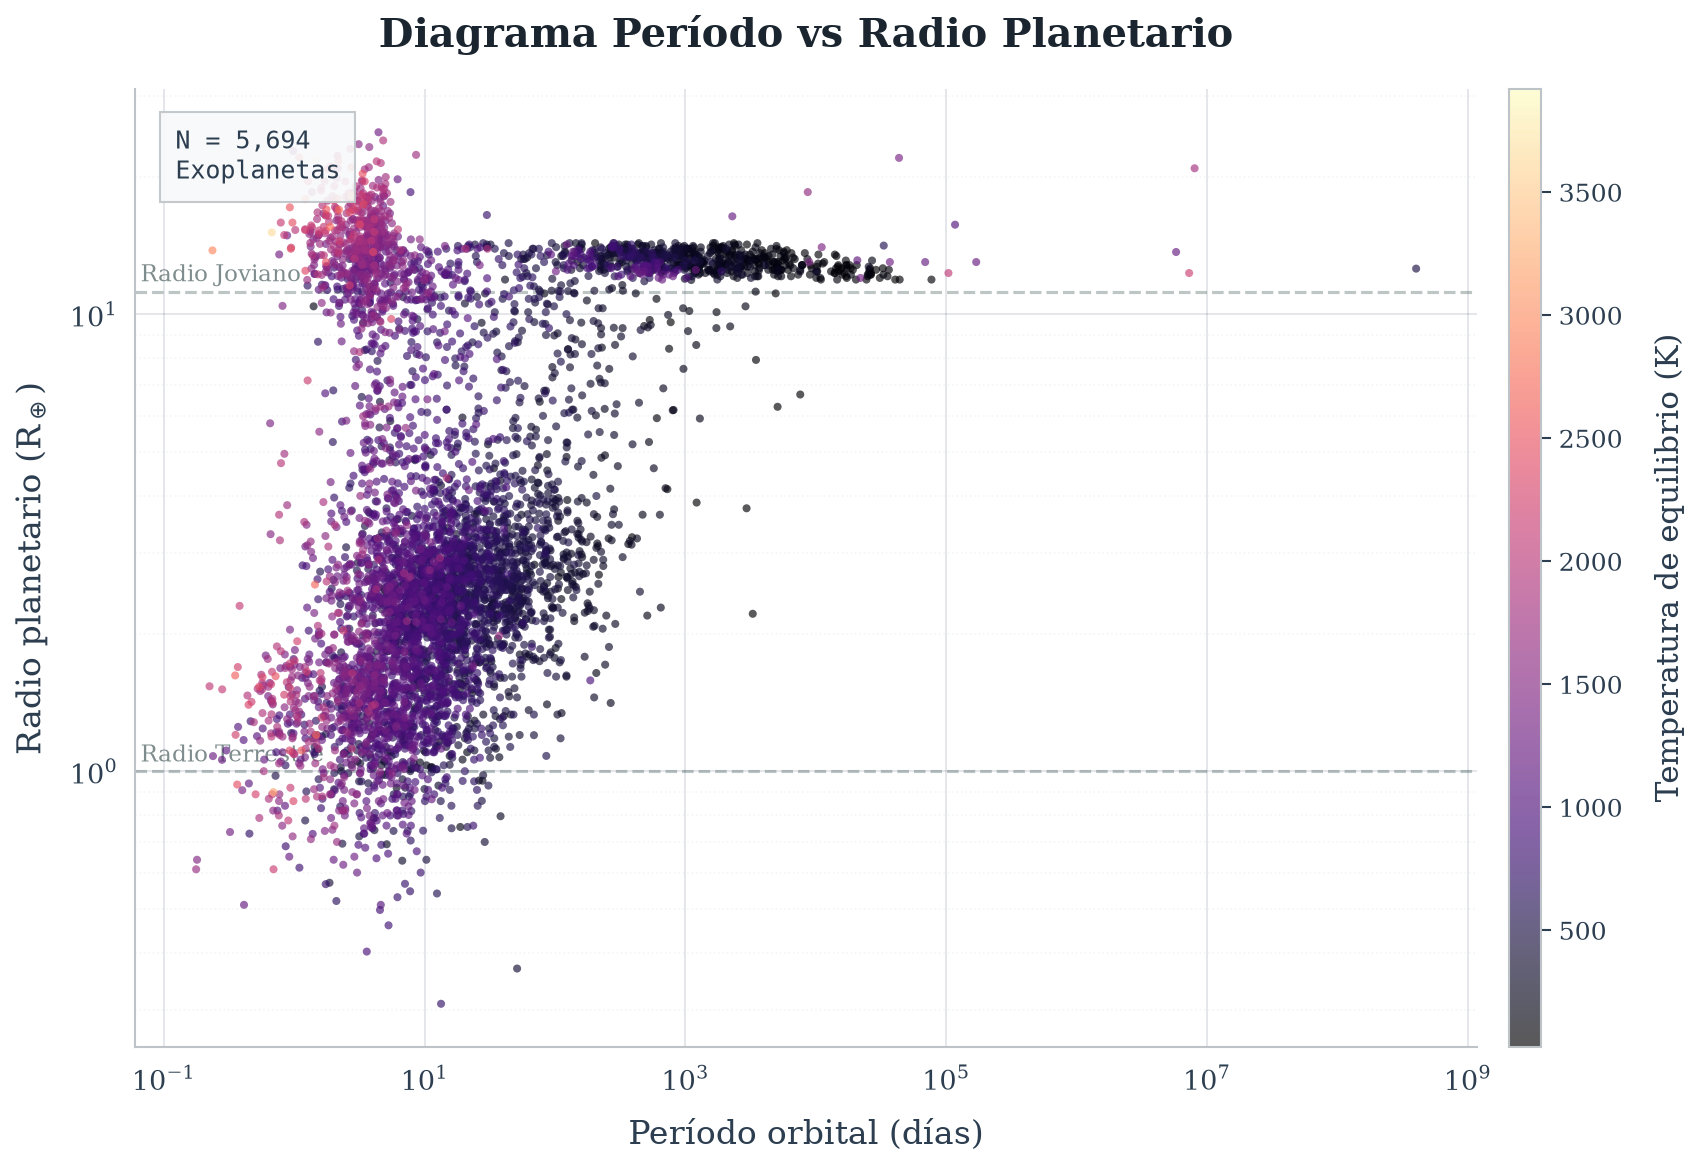

In [28]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 8))

# Ordenar los datos para los planetas calientes 
df_plot = df_all.sort_values('pl_eqt', na_position='first')

# Scatter plot optimizado 
scatter = ax.scatter(df_plot['pl_orbper'], df_plot['pl_rade'], 
                     c=df_plot['pl_eqt'], cmap='magma', 
                     s=15, alpha=0.65, edgecolors='none')

# Configuración de la barra de color
cbar = plt.colorbar(scatter, ax=ax, pad=0.02, aspect=30)
cbar.set_label('Temperatura de equilibrio (K)', fontsize=15, labelpad=15, color='#2c3e50')
cbar.ax.tick_params(labelsize=12, colors='#2c3e50')
cbar.outline.set_edgecolor('#bdc3c7')

# Escalas logarítmicas en ambos ejes
ax.set_xscale('log')
ax.set_yscale('log')

# Etiquetas y título
ax.set_xlabel('Período orbital (días)', fontsize=16, color='#2c3e50', labelpad=10)
ax.set_ylabel('Radio planetario (R$_\\oplus$)', fontsize=16, color='#2c3e50', labelpad=10)
ax.set_title('Diagrama Período vs Radio Planetario', fontweight='bold', fontsize=19, color='#1a252f', pad=20)

# Grid y marcos limpios
ax.grid(True, which='major', linestyle='-', alpha=0.15, color='#2c3e50')
ax.grid(True, which='minor', linestyle=':', alpha=0.05, color='#2c3e50')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#bdc3c7')
ax.spines['bottom'].set_color('#bdc3c7')
ax.tick_params(axis='both', which='major', labelsize=13, colors='#2c3e50')

# Líneas de referencia astronómica
ax.axhline(1, color='#7f8c8d', linestyle='--', alpha=0.5, linewidth=1.5, zorder=0)
ax.text(ax.get_xlim()[0] * 1.1, 1.05, 'Radio Terrestre', color='#7f8c8d', fontsize=11, zorder=0)

ax.axhline(11.2, color='#7f8c8d', linestyle='--', alpha=0.5, linewidth=1.5, zorder=0)
ax.text(ax.get_xlim()[0] * 1.1, 11.8, 'Radio Joviano', color='#7f8c8d', fontsize=11, zorder=0)

# Cuadro de anotación estilizado
props = dict(boxstyle='square,pad=0.6', facecolor='#f8f9fa', alpha=0.9, edgecolor='#bdc3c7', linewidth=1)
ax.text(0.03, 0.96, f'N = {len(df_all):,}\nExoplanetas', transform=ax.transAxes, 
        fontsize=12, verticalalignment='top', bbox=props, color='#2c3e50', family='monospace')

plt.tight_layout()
plt.savefig('fig2_period_radius.png', dpi=300, bbox_inches='tight')
plt.savefig('fig2_period_radius.pdf', bbox_inches='tight')
plt.show()

### **Análisis de Poblaciones Exoplanetarias: Período Orbital vs. Radio**

Este diagrama de dispersión es crucial para identificar poblaciones exoplanetarias. Al graficar el período orbital contra el radio, emergen agrupaciones claras delineadas por la física y los límites de detección:

*   **Júpiteres Calientes:** Visibles en la esquina superior izquierda (radios cercanos a $10 R_\oplus$ y períodos ultracortos). Son fáciles de detectar, pero raros en la naturaleza.

*   **El Desierto Neptuniano:** Se observa una notable escasez de planetas con el tamaño de Neptuno (alrededor de $4 R_\oplus$) en períodos muy cortos (menos de 3 días). La intensa radiación estelar a esas distancias evapora rápidamente las atmósferas de planetas intermedios. 

*   **Tierras y Súper-Tierras:** La gran nube de puntos entre $1$ y $3 R_\oplus$ con períodos entre 10 y 100 días muestra dónde se concentra el grueso de las detecciones actuales. El color, que indica la temperatura de equilibrio, confirma lógicamente que los planetas con órbitas más estrechas (períodos cortos) son significativamente más calientes.

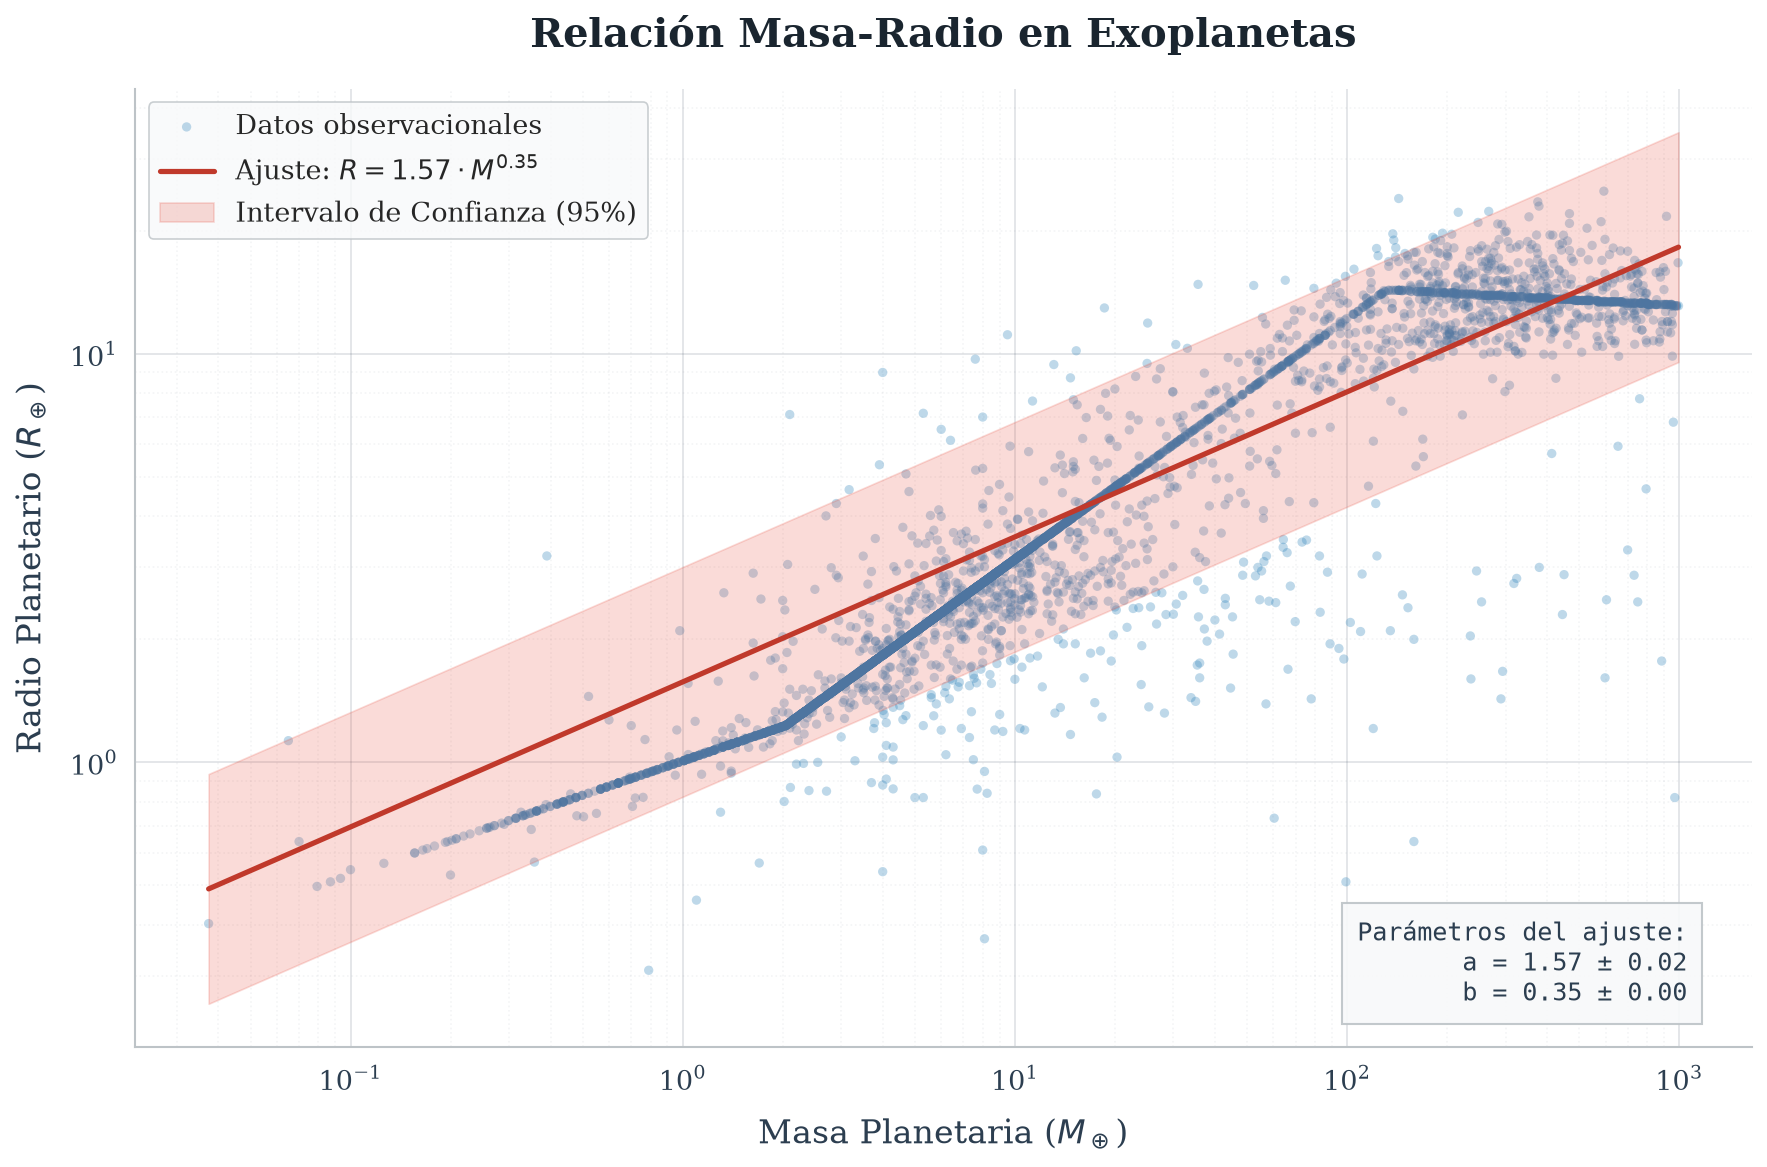

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

def power_law(M, a, b):
    return a * (M ** b)

# Filtrado de datos
df_mr = df_all[(df_all['pl_bmasse'] > 0) & (df_all['pl_rade'] > 0) & 
               (df_all['pl_bmasse'] < 1000) & (df_all['pl_rade'] < 30)].copy()

x = df_mr['pl_bmasse'].values
y = df_mr['pl_rade'].values

# Ajuste de la curva
popt, pcov = curve_fit(power_law, x, y, p0=(1, 0.5))
a_fit, b_fit = popt
perr = np.sqrt(np.diag(pcov))

x_fit = np.logspace(np.log10(x.min()), np.log10(x.max()), 100)
y_fit = power_law(x_fit, a_fit, b_fit)

# Intervalo de confianza en espacio logarítmico, calculamos el error en base logarítmica
# para que respete la escala del gráfico
log_residuals = np.log10(y) - np.log10(power_law(x, *popt))
log_std = np.std(log_residuals)

# Error de vuelta al espacio lineal multiplicando/dividiendo
y_upper = y_fit * (10 ** (1.96 * log_std))
y_lower = y_fit / (10 ** (1.96 * log_std))

# Configuración visual del lienzo
fig, ax = plt.subplots(figsize=(12, 8))

# Puntos de datos 
ax.scatter(x, y, alpha=0.3, s=20, color='#2980b9', edgecolors='none', label='Datos observacionales')

# Línea de ajuste y área de confianza 
ax.plot(x_fit, y_fit, color='#c0392b', linestyle='-', linewidth=2.5, 
        label=f'Ajuste: $R = {a_fit:.2f} \cdot M^{{{b_fit:.2f}}}$')
ax.fill_between(x_fit, y_lower, y_upper, color='#e74c3c', alpha=0.2, label='Intervalo de Confianza (95%)')

# Escalas logarítmicas
ax.set_xscale('log')
ax.set_yscale('log')

# Estética de los ejes y títulos
ax.set_xlabel('Masa Planetaria ($M_\oplus$)', fontsize=16, color='#2c3e50', labelpad=10)
ax.set_ylabel('Radio Planetario ($R_\oplus$)', fontsize=16, color='#2c3e50', labelpad=10)
ax.set_title('Relación Masa-Radio en Exoplanetas', fontweight='bold', fontsize=19, color='#1a252f', pad=20)

# Grid y marcos limpios (consistente con los gráficos anteriores)
ax.grid(True, which='major', linestyle='-', alpha=0.15, color='#2c3e50')
ax.grid(True, which='minor', linestyle=':', alpha=0.05, color='#2c3e50')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#bdc3c7')
ax.spines['bottom'].set_color('#bdc3c7')
ax.tick_params(axis='both', which='major', labelsize=13, colors='#2c3e50')

# Leyenda
ax.legend(loc='upper left', fontsize=13, frameon=True, facecolor='#f8f9fa', edgecolor='#bdc3c7')

# Cuadro de parámetros del ajuste 
props = dict(boxstyle='square,pad=0.6', facecolor='#f8f9fa', alpha=0.9, edgecolor='#bdc3c7', linewidth=1)
ax.text(0.96, 0.04, f'Parámetros del ajuste:\na = {a_fit:.2f} ± {perr[0]:.2f}\nb = {b_fit:.2f} ± {perr[1]:.2f}', 
        transform=ax.transAxes, fontsize=12, verticalalignment='bottom', horizontalalignment='right',
        bbox=props, color='#2c3e50', family='monospace')

plt.tight_layout()
plt.savefig('fig3_mass_radius.png', dpi=300, bbox_inches='tight')
plt.savefig('fig3_mass_radius.pdf', bbox_inches='tight')
plt.show()


### **Relación Masa-Radio en Exoplanetas**

Desde una perspectiva de ingeniería física y dinámica estelar, la relación empírica entre la masa y el radio es la llave para entender la composición interna de un planeta. El ajuste de la ley de potencias arroja la siguiente ecuación:

$$R = 1.57 \cdot M^{0.35}$$

*   **Régimen Rocoso vs. Gaseoso:** La dispersión de los datos muestra que los planetas no siguen una única línea estricta de evolución, debido a que la densidad promedio varía radicalmente entre mundos rocosos (baja masa, bajo radio) y gigantes gaseosos (alta masa, alto radio).

*   **Inflexión estructural:** Cerca de las $100 M_\oplus$ (aproximadamente la masa de Saturno), la curva tiende a aplanarse notablemente. Esto ocurre porque añadir más masa a un gigante gaseoso no aumenta su volumen de forma proporcional; en su lugar, la masa adicional comprime gravitacionalmente la materia del núcleo. El intervalo de confianza del **95%** ilustra la gran variabilidad estructural (núcleos rocosos densos vs. envolturas extendidas de H/He) que puede presentar un planeta para una misma masa.



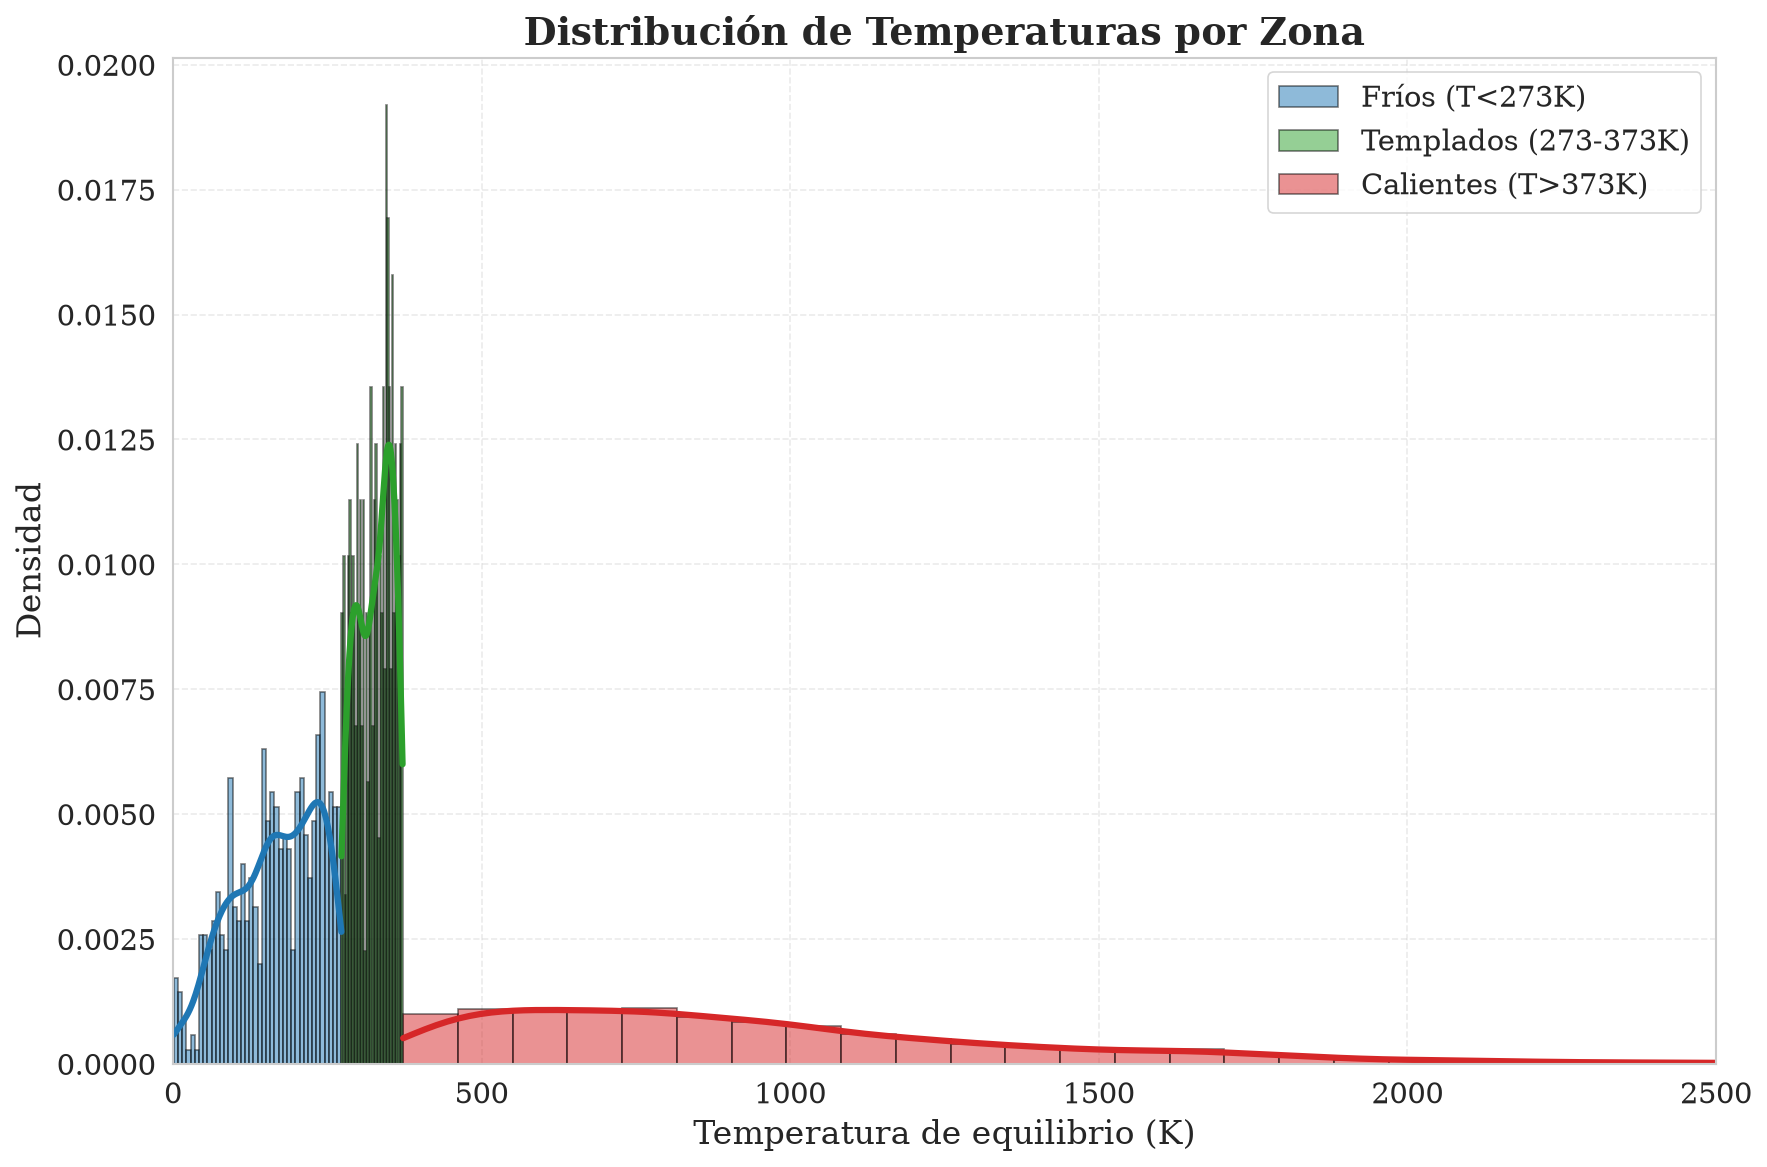

In [30]:
fig, ax = plt.subplots(figsize=(12, 8))
zone_colors = {'Cold': '#1f77b4', 'Temperate': '#2ca02c', 'Hot': '#d62728'}
zone_labels = {'Cold': 'Fríos (T<273K)', 'Temperate': 'Templados (273-373K)', 'Hot': 'Calientes (T>373K)'}

for zone, color in zone_colors.items():
    data = df_all[df_all['temp_zone'] == zone]['pl_eqt']
    if len(data) > 0:
        ax.hist(data, bins=40, alpha=0.5, density=True, label=zone_labels[zone], color=color, edgecolor='black')
        # KDE
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(data)
        x_range = np.linspace(data.min(), data.max(), 200)
        ax.plot(x_range, kde(x_range), color=color, lw=3)

ax.set_xlabel('Temperatura de equilibrio (K)', fontsize=16)
ax.set_ylabel('Densidad', fontsize=16)
ax.set_title('Distribución de Temperaturas por Zona', fontweight='bold', fontsize=18)
ax.legend(loc='upper right', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.4)
ax.tick_params(labelsize=14)
ax.set_xlim(0, 2500)
plt.tight_layout()
plt.savefig('fig4_temp_hist.png', dpi=300)
plt.savefig('fig4_temp_hist.pdf')
plt.show()

### **Distribución de Temperaturas por Zona**

Este histograma de densidad revela otro profundo sesgo de selección en las bases de datos de catalogación exoplanetaria. 

*   **Sesgo hacia mundos "Calientes":** La inmensa mayoría de los exoplanetas caracterizados caen en la categoría de altas temperaturas ($T > 373\text{ K}$).

*   **Geometría observacional:** La probabilidad geométrica de que un planeta transite frente a su estrella aumenta drásticamente cuanto menor es la distancia orbital. Asimismo, la señal de velocidad radial inducida en la estrella es mucho más fuerte.

*   **Subrepresentación de la habitabilidad:** Los planetas similares a Júpiter o Saturno en nuestro Sistema Solar y los planetas rocosos en la zona de habitabilidad ("Templados") están severamente subrepresentados. Esto no se debe a su inexistencia, sino a que requieren décadas de observación continua para confirmarse.



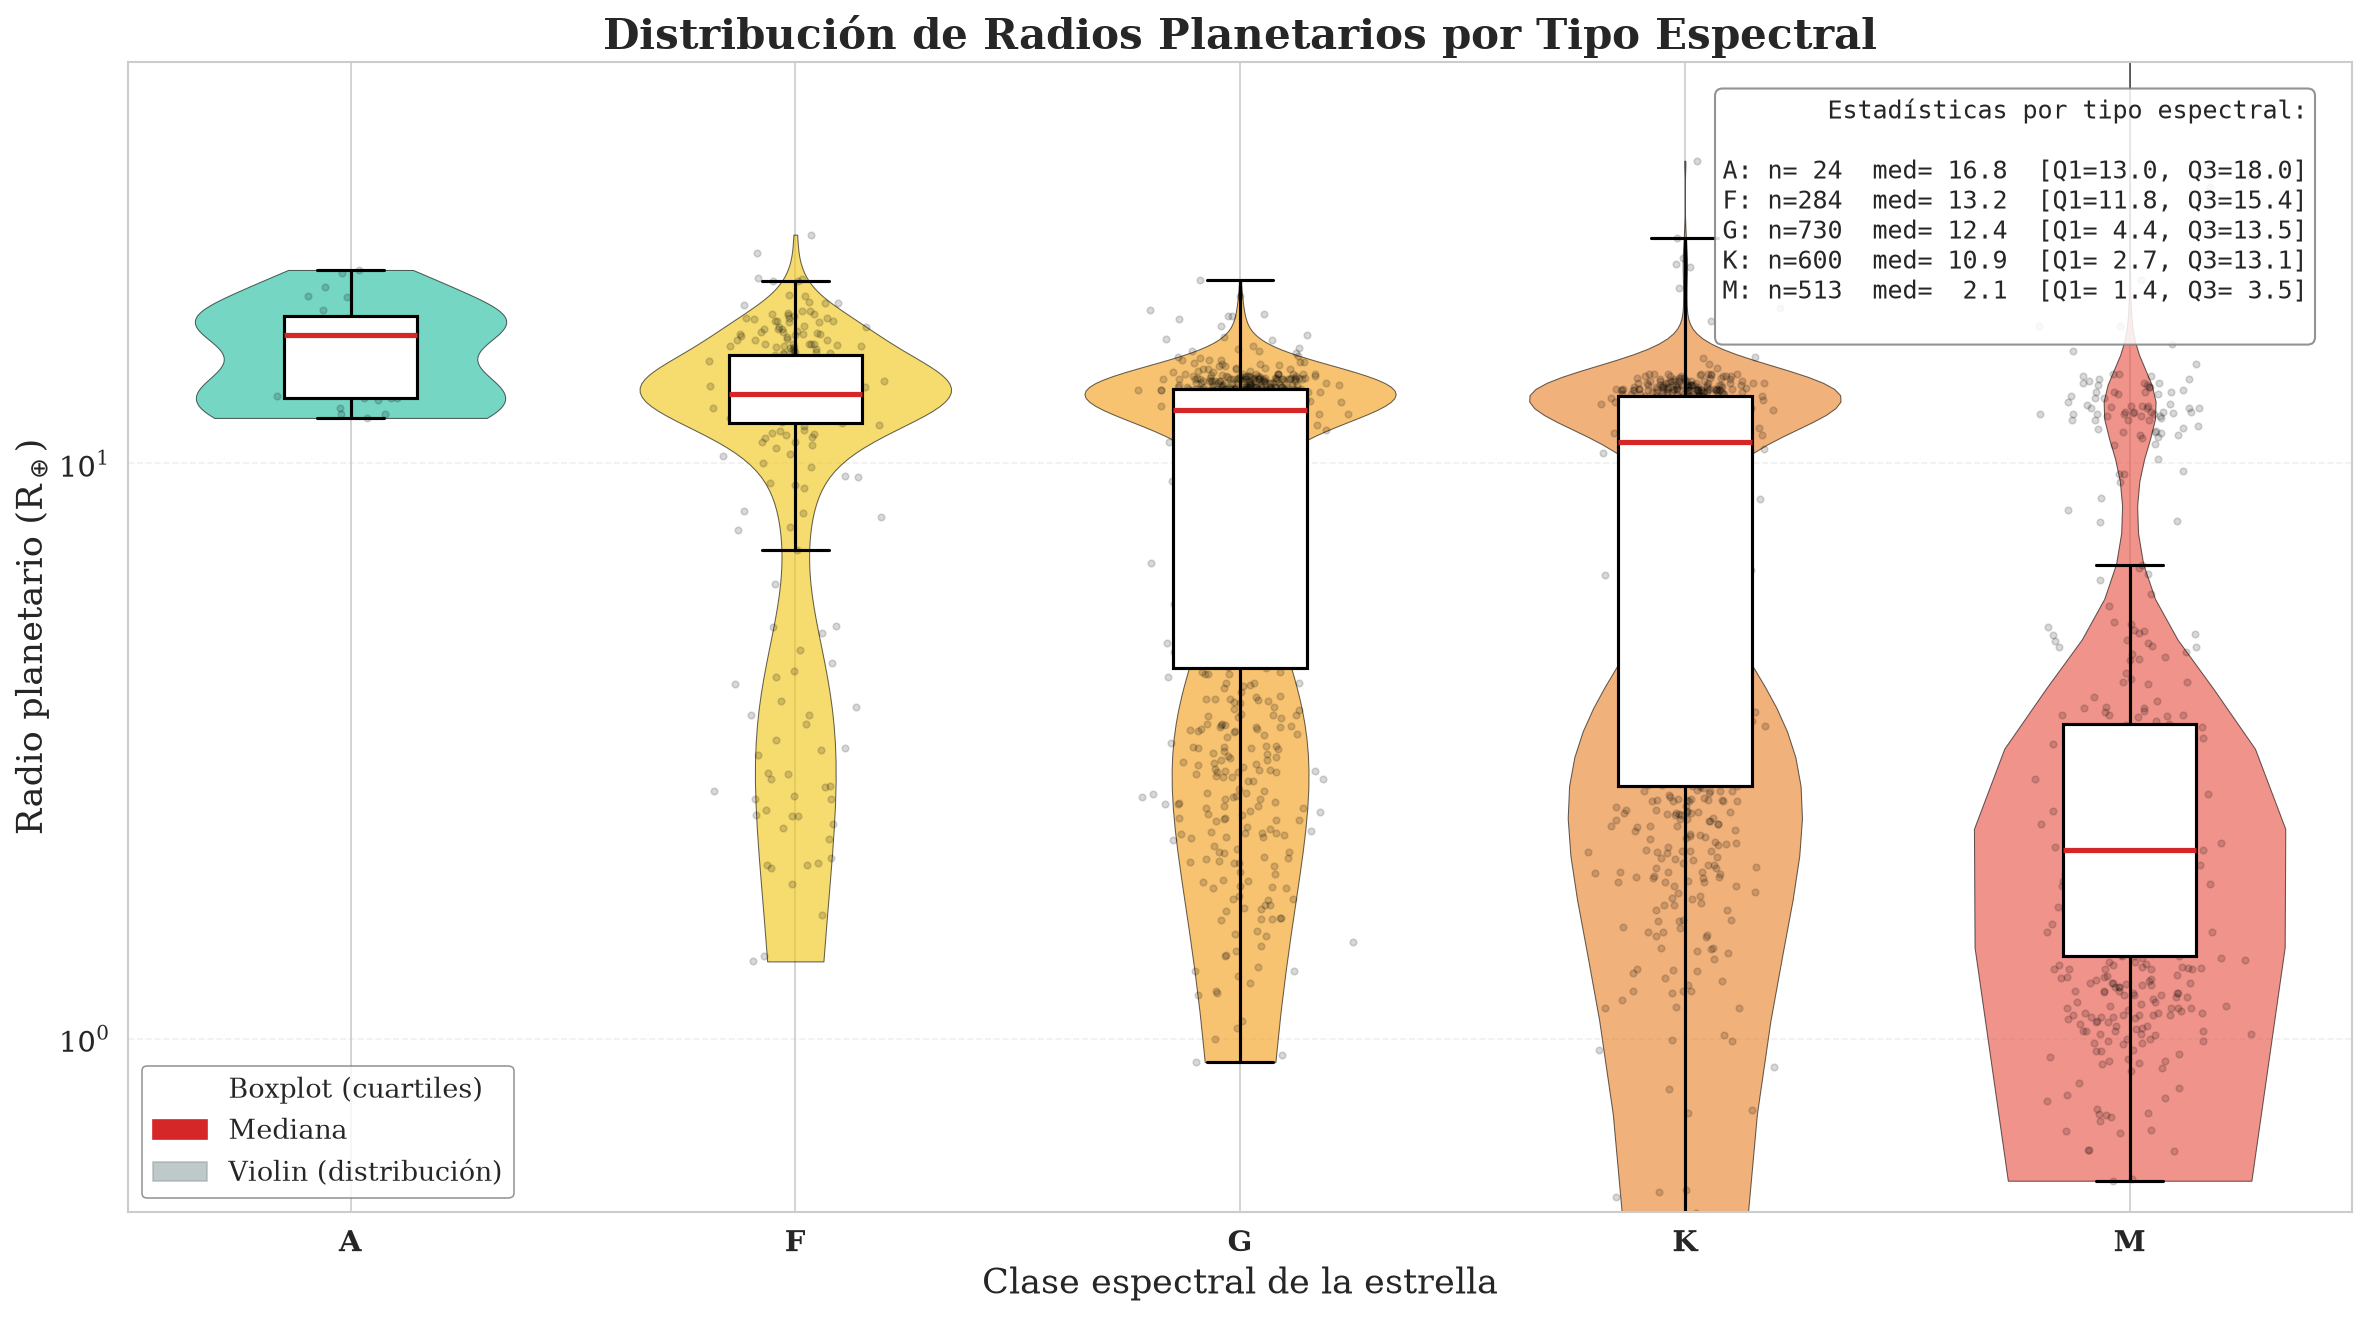

In [31]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(16, 9))

# Preparar datos
df_st = df_all[df_all['st_spectype'].notna()]
df_st['spec_class'] = df_st['st_spectype'].str[0]

# Filtrar tipos con al menos 10 planetas para evitar ruido
spec_counts = df_st['spec_class'].value_counts()
top_spec = spec_counts[spec_counts >= 10].index.tolist()

# Orden espectral correcto
orden_espectral = ['O', 'B', 'A', 'F', 'G', 'K', 'M']
orden = [c for c in orden_espectral if c in top_spec]
df_st_top = df_st[df_st['spec_class'].isin(orden)].copy()
df_st_top['spec_class'] = pd.Categorical(df_st_top['spec_class'], categories=orden, ordered=True)
df_st_top = df_st_top.sort_values('spec_class')

# Colores profesionales para cada tipo espectral
spec_colors = {
    'O': '#9b59b6',  # Púrpura
    'B': '#3498db',  # Azul
    'A': '#1abc9c',  # Turquesa
    'F': '#f1c40f',  # Amarillo
    'G': '#f39c12',  # Naranja
    'K': '#e67e22',  # Naranja oscuro
    'M': '#e74c3c'   # Rojo
}

# Violin plots (distribución completa)
violin_parts = ax.violinplot(
    [df_st_top[df_st_top['spec_class'] == s]['pl_rade'].values for s in orden],
    positions=range(len(orden)),
    widths=0.7,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

# Colorear violines
for i, pc in enumerate(violin_parts['bodies']):
    pc.set_facecolor(spec_colors.get(orden[i], '#95a5a6'))
    pc.set_alpha(0.6)
    pc.set_edgecolor('black')
    pc.set_linewidth(0.5)

# Boxplots superpuestos 
box = ax.boxplot(
    [df_st_top[df_st_top['spec_class'] == s]['pl_rade'].values for s in orden],
    positions=range(len(orden)),
    widths=0.3,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor='white', edgecolor='black', linewidth=1.5),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5),
    medianprops=dict(color='#d62728', linewidth=2.5),
)

# Puntos individuales (jitter) 
for i, spec in enumerate(orden):
    data = df_st_top[df_st_top['spec_class'] == spec]['pl_rade'].values
    # Agregar ruido horizontal
    x_jitter = np.random.normal(i, 0.08, size=len(data))
    ax.scatter(x_jitter, data, color='black', alpha=0.15, s=10)

# 4. Estadísticas en un panel lateral
stats_text = "Estadísticas por tipo espectral:\n\n"
for spec in orden:
    data = df_st_top[df_st_top['spec_class'] == spec]['pl_rade'].values
    n = len(data)
    med = np.median(data)
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    stats_text += f"{spec}: n={n:3d}  med={med:5.1f}  [Q1={q1:4.1f}, Q3={q3:4.1f}]\n"

# Añadir cuadro de estadísticas
props = dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='gray', linewidth=1)
ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', horizontalalignment='right',
        bbox=props, family='monospace')

# Configuración de ejes
ax.set_xticks(range(len(orden)))
ax.set_xticklabels(orden, fontsize=18, fontweight='bold')
ax.set_xlabel('Clase espectral de la estrella', fontsize=17)
ax.set_ylabel('Radio planetario (R$_\\oplus$)', fontsize=17)
ax.set_title('Distribución de Radios Planetarios por Tipo Espectral', fontweight='bold', fontsize=20)

# Escala logarítmica para mejor visualización
ax.set_yscale('log')
ax.set_ylim(0.5, 50)

# Grid sutil
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.tick_params(axis='both', labelsize=14)

# Leyenda personalizada
legend_elements = [
    mpatches.Patch(color='white', edgecolor='black', label='Boxplot (cuartiles)'),
    mpatches.Patch(color='#d62728', edgecolor='black', label='Mediana'),
    mpatches.Patch(color='#95a5a6', alpha=0.6, label='Violin (distribución)'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=13, frameon=True, facecolor='white', edgecolor='gray')

plt.tight_layout()
plt.savefig('fig5_spectral_box.png', dpi=300)
plt.savefig('fig5_spectral_box.pdf')
plt.show()

### **Distribución de Radios Planetarios por Tipo Espectral**

Este gráfico de violín segmenta la arquitectura de los sistemas planetarios según la masa y temperatura de su estrella anfitriona.

*   **Estrellas tipo M (Enanas Rojas):** La distribución (color rojo) tiene una mediana muy baja ($2.1 R_\oplus$), concentrándose fuertemente en Súper-Tierras y mundos de escala terrestre. Encontrar gigantes gaseosos alrededor de estrellas M es estadísticamente poco probable debido a la menor cantidad de masa disponible en sus discos protoplanetarios.

*   **Estrellas tipo F, G y K (Similares al Sol):** Presentan distribuciones mucho más amplias hacia la parte superior (con medianas superiores a $10 R_\oplus$). Los discos protoplanetarios más masivos de estas estrellas permiten la rápida formación de núcleos gigantes antes de que el gas nebular se disipe.



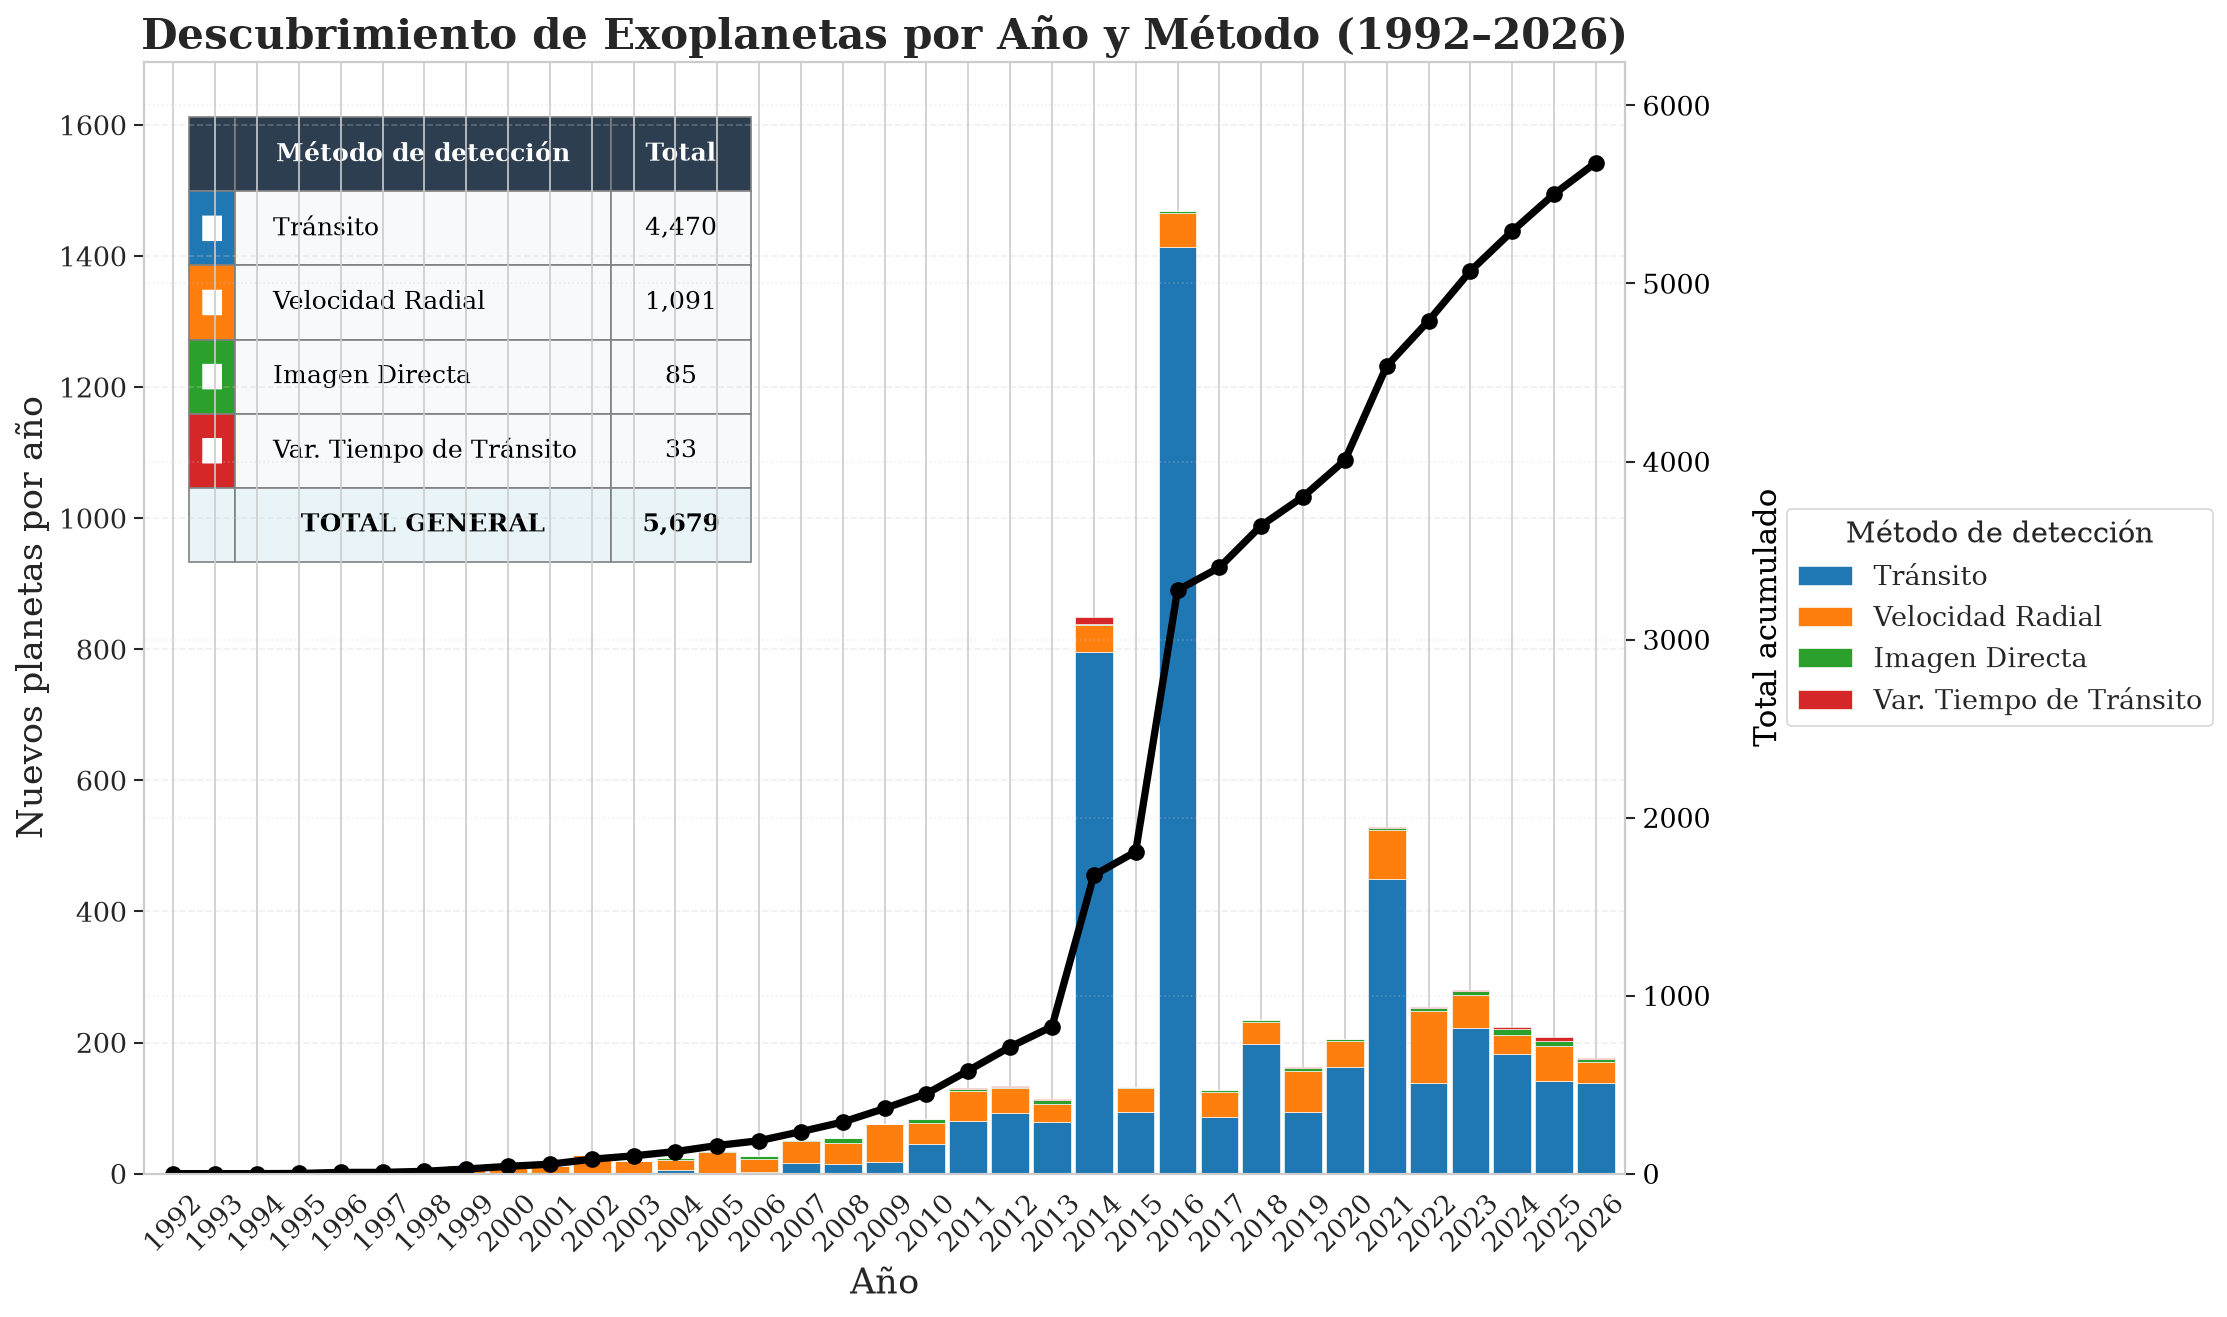

In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(18, 9))

# Preparación de datos 

df_year_method = df_all.groupby(['disc_year', 'discoverymethod']).size().reset_index(name='count')
years = np.arange(1992, 2027)
pivot = df_year_method.pivot(index='disc_year', columns='discoverymethod', values='count').fillna(0)
pivot = pivot.reindex(years, fill_value=0)

# Métodos con más de 10 detecciones
method_totals = pivot.sum().sort_values(ascending=False)
top_methods = method_totals[method_totals > 10].index.tolist()
pivot_top = pivot[top_methods]

# Nombres profesionales para la tabla y leyenda

nombres_metodos = {
    'Transit': 'Tránsito',
    'Radial Velocity': 'Velocidad Radial',
    'Imaging': 'Imagen Directa',
    'Transit Timing Variations': 'Var. Tiempo de Tránsito',
    'Microlensing': 'Microlente Gravitacional',
    'Astrometry': 'Astrometría',
    'Eclipse Timing Variations': 'Var. Tiempo de Eclipse',
    'Orbital Brightness Modulation': 'Modulación de Brillo'
}

# Renombrar columnas para estandarizar
pivot_top = pivot_top.rename(columns=nombres_metodos)

# Colores actualizados con las nuevas llaves
method_colors = {
    'Tránsito': '#1f77b4',
    'Velocidad Radial': '#ff7f0e',
    'Imagen Directa': '#2ca02c',
    'Var. Tiempo de Tránsito': '#d62728',
    'Microlente Gravitacional': '#9467bd',
    'Astrometría': '#8c564b',
    'Var. Tiempo de Eclipse': '#e377c2',
    'Modulación de Brillo': '#7f7f7f'
}
colors = [method_colors.get(m, '#95a5a6') for m in pivot_top.columns]

# Barras apiladas
pivot_top.plot(kind='bar', stacked=True, ax=ax, color=colors, width=0.9, edgecolor='white', linewidth=0.3)

# Línea acumulada 
# Usamos np.arange para que la línea coincida con el eje categórico de las barras de Pandas
cumulative = pivot_top.sum(axis=1).cumsum()
ax2 = ax.twinx()

x_coords = np.arange(len(pivot_top.index))
ax2.plot(x_coords, cumulative, 
         color='black', linestyle='-', linewidth=3.5, marker='o', markersize=7,
         label='Total acumulado')

# Textos en negro y separados
ax2.set_ylabel('Total acumulado', fontsize=15, color='black', labelpad=20)
ax2.tick_params(axis='y', labelcolor='black', labelsize=13)
ax2.grid(axis='y', linestyle=':', alpha=0.3)
ax2.set_ylim(0, cumulative.max() * 1.1)

# Tabla de totales acumulados
totals = pivot_top.sum().sort_values(ascending=False)
total_general = cumulative.iloc[-1]

table_data = [['', 'Método de detección', 'Total']]
for method, total in totals.items():
    color = method_colors.get(method, '#95a5a6')
    color_box = '█'
    total_str = f'{int(total):,}'
    table_data.append([color_box, method, total_str])

table_data.append(['', 'TOTAL GENERAL', f'{int(total_general):,}'])

# Ubicada a la izquierda con anchos de columna ajustados
table = ax.table(cellText=table_data, loc='upper left', 
                 cellLoc='center', colWidths=[0.05, 0.40, 0.15],
                 bbox=[0.03, 0.55, 0.38, 0.40]) 

# Estilo de la tabla
table.auto_set_font_size(False)
table.set_fontsize(12)

for (i, j), cell in table.get_celld().items():
    if i == 0:  
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(weight='bold', color='white')
    elif i == len(table_data) - 1:  
        cell.set_facecolor('#e8f4f8')
        cell.set_text_props(weight='bold', color='black')
    else:
        if j == 0:  
            method = table_data[i][1]
            color = method_colors.get(method, '#95a5a6')
            cell.set_facecolor(color)
            cell.set_text_props(color='white')
        else:
            cell.set_facecolor('#f8f9fa')
            cell.set_text_props(color='black')
            
        # Alinear los nombres a la izquierda para mejor lectura
        if j == 1:
            cell.set_text_props(ha='left')
            
    cell.set_edgecolor('gray')
    cell.set_linewidth(0.8)

# Configuración del eje principal
ax.set_xlabel('Año', fontsize=17)
ax.set_ylabel('Nuevos planetas por año', fontsize=17)
ax.set_title('Descubrimiento de Exoplanetas por Año y Método (1992–2026)', fontweight='bold', fontsize=20)

# Leyenda externa desplazada para evitar solapamiento
ax.legend(title='Método de detección', bbox_to_anchor=(1.10, 0.5), loc='center left', fontsize=13, title_fontsize=14)

ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.tick_params(axis='x', rotation=45, labelsize=13)
ax.tick_params(axis='y', labelsize=13)

ax.set_ylim(0, pivot_top.max().max() * 1.2)

# Ajuste para que los textos de la derecha no se tapen
plt.tight_layout(rect=[0, 0, 0.86, 1])

plt.savefig('fig6_timeline.png', dpi=300)
plt.savefig('fig6_timeline.pdf')
plt.show()

### **Línea de Tiempo de Descubrimientos por Año y Método**

La evolución histórica de la exoplanetología moderna queda retratada de forma cronológica en este gráfico de barras apiladas. 

*   **El dominio inicial:** Hasta 2013, los descubrimientos se daban a un ritmo lento y controlado, liderado principalmente por la técnica de Velocidad Radial (naranja).

*   **El impacto de Kepler:** Los colosales picos observados en los años 2014 y 2016 marcan los hitos de validación estadística masiva de los candidatos detectados por la misión espacial *Kepler*.

*   **Crecimiento exponencial:** La curva negra de total acumulado demuestra una pendiente casi vertical en la última década, pasando de un puñado de planetas en los años 90 a casi 6,000 en la actualidad. Es una muestra de la madurez de la instrumentación y la astrofísica computacional.



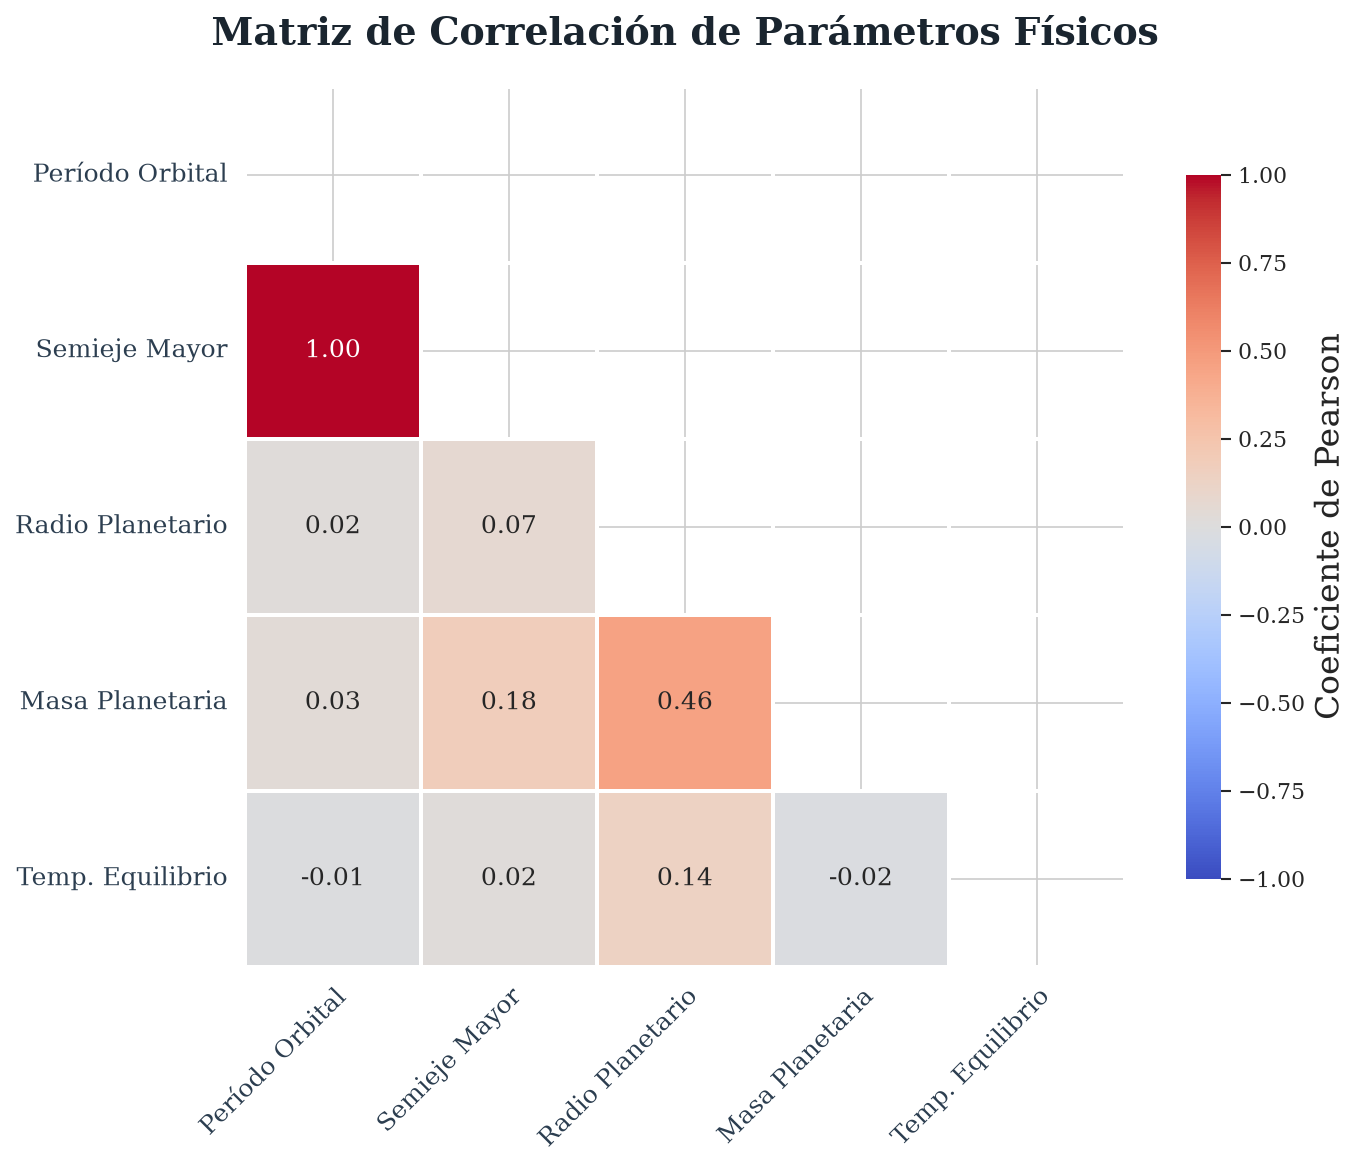

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

fig, ax = plt.subplots(figsize=(10, 8))

numeric_cols = ['pl_orbper', 'pl_orbsmax', 'pl_rade', 'pl_bmasse', 'pl_eqt']

# Nombres legibles para los ejes
nombres_legibles = [
    'Período Orbital', 
    'Semieje Mayor', 
    'Radio Planetario', 
    'Masa Planetaria', 
    'Temp. Equilibrio'
]

# Calcular correlación
corr = df_all[numeric_cols].corr()

# Crear una máscara para ocultar la mitad superior 
mask = np.triu(np.ones_like(corr, dtype=bool))

# Crear el Heatmap
sns.heatmap(corr, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0, 
            vmin=-1, vmax=1, # Fija los límites de -1 a 1 para que el color sea representativo
            linewidths=1, 
            linecolor='white',
            square=True, 
            cbar_kws={"shrink": 0.8, "label": "Coeficiente de Pearson"}, 
            mask=mask, 
            xticklabels=nombres_legibles, 
            yticklabels=nombres_legibles,
            annot_kws={"size": 12}, # Tamaño del texto de los números
            ax=ax)

# Configuración de textos
ax.set_title('Matriz de Correlación de Parámetros Físicos', fontweight='bold', fontsize=18, color='#1a252f', pad=20)
ax.tick_params(axis='x', rotation=45, labelsize=12, colors='#2c3e50')
ax.tick_params(axis='y', rotation=0, labelsize=12, colors='#2c3e50')

# Alinear las etiquetas del eje X a la derecha para que no se solapen
plt.setp(ax.get_xticklabels(), ha="right", rotation_mode="anchor")

plt.tight_layout()
plt.savefig('fig7_corr.png', dpi=300, bbox_inches='tight')
plt.savefig('fig7_corr.pdf', bbox_inches='tight')
plt.show()

### **Matriz de Correlación de Parámetros Físicos**

El mapa de calor proporciona una confirmación estadística directa de las leyes fundamentales de la mecánica celeste.

*   **Correlación matemática perfecta (1.00):** La fuerte relación lineal entre el Período Orbital y el Semieje Mayor es simplemente la observación empírica de la Tercera Ley de Kepler ($P^2 \propto a^3$).

*   **Correlaciones intermedias:** El índice de **0.46** entre Masa y Radio confirma la tendencia térmica y de composición: a mayor masa, mayor volumen, aunque atenuado por las variaciones en el estado de la materia interior.

*   **Ausencias de linealidad:** El valor cercano a cero entre la Temperatura de Equilibrio y el Semieje Mayor ocurre porque la matriz busca relaciones estrictamente *lineales*, mientras que físicamente la temperatura decae de forma inversamente proporcional a la raíz cuadrada de la distancia ($T \propto a^{-1/2}$).


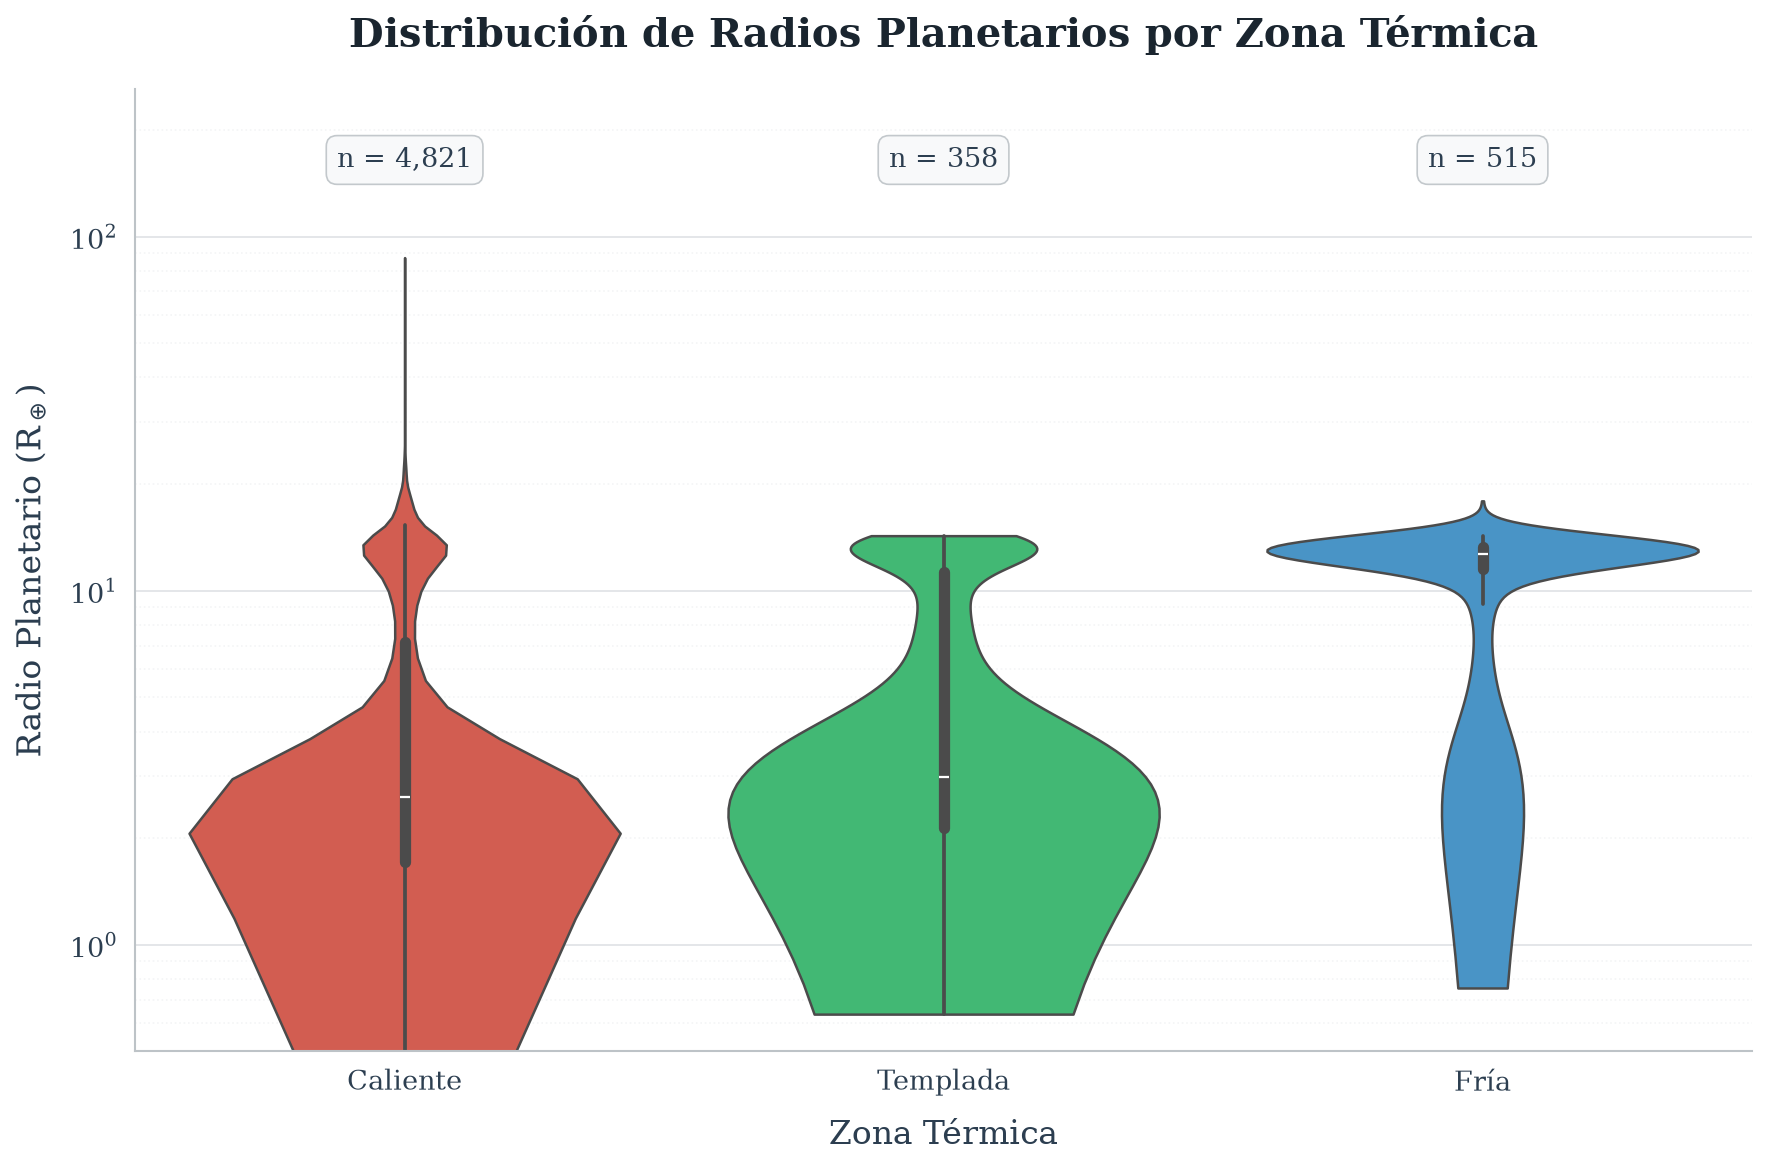

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, ax = plt.subplots(figsize=(12, 8))

# 1. Limpieza y traducción de datos
# Aseguramos que no haya radios en 0 o negativos para la escala logarítmica
df_plot = df_all[df_all['pl_rade'] > 0].copy()

mapa_zonas = {'Hot': 'Caliente', 'Temperate': 'Templada', 'Cold': 'Fría'}
df_plot['Zona'] = df_plot['temp_zone'].map(mapa_zonas)

# Definimos el orden y una paleta de colores profesional
orden_zonas = ['Caliente', 'Templada', 'Fría']
colores_zonas = {
    'Caliente': '#e74c3c', # Rojo
    'Templada': '#2ecc71', # Verde
    'Fría': '#3498db'      # Azul
}

# Creación del Violin Plot
sns.violinplot(
    data=df_plot, 
    x='Zona', 
    y='pl_rade', 
    order=orden_zonas,
    palette=colores_zonas, 
    inner='box',       # Muestra un boxplot miniatura dentro del violín
    linewidth=1.2,
    cut=0,             # Corta el violín exactamente en los límites de los datos
    ax=ax
)

# Escala Logarítmica 
ax.set_yscale('log')

# Configuración de ejes y títulos
ax.set_xlabel('Zona Térmica', fontsize=16, color='#2c3e50', labelpad=10)
ax.set_ylabel('Radio Planetario (R$_\oplus$)', fontsize=16, color='#2c3e50', labelpad=10)
ax.set_title('Distribución de Radios Planetarios por Zona Térmica', fontweight='bold', fontsize=19, color='#1a252f', pad=20)

# Estilo para la grilla y los marcos
ax.grid(axis='y', which='major', linestyle='-', alpha=0.15, color='#2c3e50')
ax.grid(axis='y', which='minor', linestyle=':', alpha=0.05, color='#2c3e50')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#bdc3c7')
ax.spines['bottom'].set_color('#bdc3c7')
ax.tick_params(axis='both', labelsize=13, colors='#2c3e50')

# Espacio extra en la parte superior para las etiquetas
ax.set_ylim(bottom=0.5, top=df_plot['pl_rade'].max() * 3)

# Añadir conteos (n=...) alineados 
for i, zona in enumerate(orden_zonas):
    n_count = len(df_plot[df_plot['Zona'] == zona])
    if n_count > 0:
        # get_xaxis_transform() mezcla coordenadas de datos en X y coordenadas relativas (0 a 1) en Y
        ax.text(i, 0.94, f'n = {n_count:,}', 
                transform=ax.get_xaxis_transform(), 
                ha='center', va='top', fontsize=13, color='#2c3e50',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f9fa', edgecolor='#bdc3c7', alpha=0.9))

plt.tight_layout()
plt.savefig('fig8_violin.png', dpi=300, bbox_inches='tight')
plt.savefig('fig8_violin.pdf', bbox_inches='tight')
plt.show()

### **Distribución de Radios Planetarios por Zona Térmica**

Al visualizar los radios en una escala logarítmica segmentada por zona de irradiación, se evidencia una clara bimodalidad en la zona "Caliente".

*   **Violín de planetas Calientes:** Presenta dos abultamientos marcados: uno inferior correspondiente a planetas rocosos ultracortos (mundos de lava) y uno superior de gran volumen que aloja a Júpiteres Calientes térmicamente inflados.

*   **Zonas "Templada" y "Fría":** Tienen una morfología de densidad diferente, agrupándose de forma más homogénea en radios intermedios. Los escasos planetas detectados en la zona fría ilustran el límite instrumental para resolver cuerpos pequeños a grandes distancias de sus estrellas.



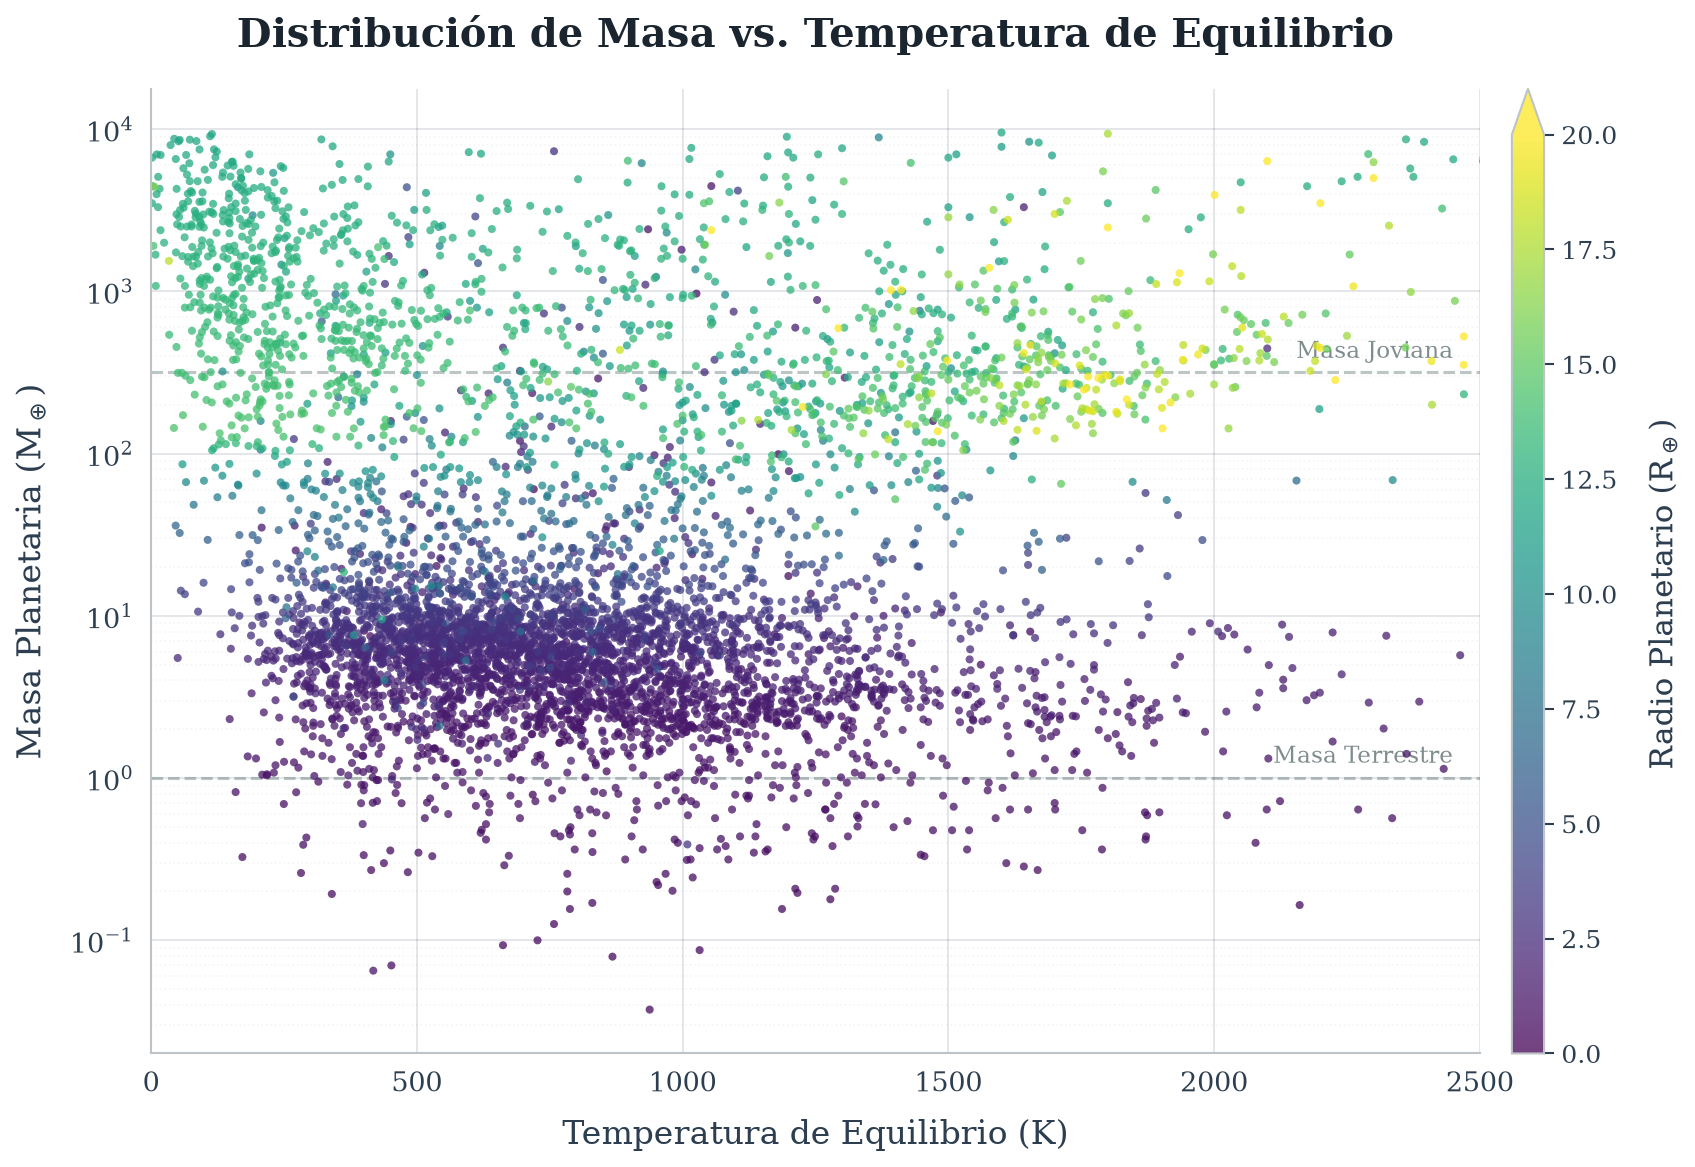

In [35]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 8))

# Ordenar datos para que los planetas de mayor radio se dibujen al final
df_plot = df_all.sort_values('pl_rade', na_position='first')

# Scatter plot con límite superior en el colormap (vmax=20) para evitar que outliers arruinen la escala
scatter9 = ax.scatter(df_plot['pl_eqt'], df_plot['pl_bmasse'], 
                      c=df_plot['pl_rade'], cmap='viridis', 
                      s=15, alpha=0.75, edgecolors='none', 
                      vmin=0, vmax=20) # Límite físico razonable para planetas

# Configuración de la barra de color (extend='max' indica que hay valores por encima del límite)
cbar9 = plt.colorbar(scatter9, ax=ax, pad=0.02, aspect=30, extend='max')
cbar9.set_label('Radio Planetario (R$_\\oplus$)', fontsize=15, labelpad=15, color='#2c3e50')
cbar9.ax.tick_params(labelsize=12, colors='#2c3e50')
cbar9.outline.set_edgecolor('#bdc3c7')

# Escalas y límites
ax.set_yscale('log')
ax.set_xlim(0, 2500)

# Estética de ejes y títulos
ax.set_xlabel('Temperatura de Equilibrio (K)', fontsize=16, color='#2c3e50', labelpad=10)
ax.set_ylabel('Masa Planetaria (M$_\\oplus$)', fontsize=16, color='#2c3e50', labelpad=10)
ax.set_title('Distribución de Masa vs. Temperatura de Equilibrio', fontweight='bold', fontsize=19, color='#1a252f', pad=20)

# Grid y marcos limpios
ax.grid(True, which='major', linestyle='-', alpha=0.15, color='#2c3e50')
ax.grid(True, which='minor', linestyle=':', alpha=0.05, color='#2c3e50')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#bdc3c7')
ax.spines['bottom'].set_color('#bdc3c7')
ax.tick_params(axis='both', which='major', labelsize=13, colors='#2c3e50')

# Líneas de referencia astronómica
ax.axhline(1, color='#7f8c8d', linestyle='--', alpha=0.5, linewidth=1.5, zorder=0)
ax.text(2450, 1.15, 'Masa Terrestre', color='#7f8c8d', fontsize=11, zorder=0, ha='right', va='bottom')

ax.axhline(317.8, color='#7f8c8d', linestyle='--', alpha=0.5, linewidth=1.5, zorder=0)
ax.text(2450, 360, 'Masa Joviana', color='#7f8c8d', fontsize=11, zorder=0, ha='right', va='bottom')

plt.tight_layout()
plt.savefig('fig9_mass_temp.png', dpi=300, bbox_inches='tight')
plt.savefig('fig9_mass_temp.pdf', bbox_inches='tight')
plt.show()

### **Distribución de Masa vs. Temperatura de Equilibrio**

Este espacio de fase (Masa vs. Temperatura) consolida la demografía exoplanetaria general y los procesos de interacción estrella-planeta.

*   **Júpiteres Calientes:** Se acumulan en la parte superior derecha (altas masas y altas temperaturas). Su gran radio promedio se debe a que la inmensa radiación estelar infla las capas externas de sus envolturas de hidrógeno y helio.
*   **Tierras y Súper-Tierras:** Se concentran con abundancia en la franja inferior de masas.

*   **El Valle de la Fotoevaporación:** Destaca visualmente la ausencia de planetas en la zona superior central (temperaturas mayores a $1500\text{ K}$ y masas entre $10$ y $100 M_\oplus$). Este vacío de datos corrobora la hipótesis de evaporación atmosférica: un planeta gaseoso de masa neptuniana que orbite demasiado cerca de su estrella perderá su envoltura gaseosa por la radiación ultravioleta y de rayos X extremos, dejando expuesto únicamente su núcleo rocoso desnudo y desplazándose estadísticamente hacia la parte inferior del gráfico.

## **Exportación final**

In [4]:
# Generar dashboard.pdf
import matplotlib.backends.backend_pdf
import matplotlib.pyplot as plt

with matplotlib.backends.backend_pdf.PdfPages('dashboard.pdf') as pdf:
    # Cambiamos el rango a (1, 10) para que incluya del 1 al 9
    for i in range(1, 10):
        img_path = f'fig{i}_methods.png' if i==1 else f'fig{i}_period_radius.png' if i==2 else f'fig{i}_mass_radius.png' if i==3 else f'fig{i}_temp_hist.png' if i==4 else f'fig{i}_spectral_box.png' if i==5 else f'fig{i}_timeline.png' if i==6 else f'fig{i}_corr.png' if i==7 else f'fig{i}_violin.png' if i==8 else f'fig{i}_mass_temp.png'
        img = plt.imread(img_path)
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.imshow(img)
        ax.axis('off')
        pdf.savefig(fig)
        plt.close(fig)

print("✅ dashboard.pdf generado.")

 # requirements.txt

requirements = """astropy>=5.0
astroquery>=0.4.6
numpy>=1.21
pandas>=1.3
scipy>=1.7
matplotlib>=3.4
seaborn>=0.11
ipython>=7.0
jupyter>=1.0
requests>=2.25

"""
with open('requirements.txt', 'w') as f:
    f.write(requirements)
print("✅ requirements.txt generado.") 

✅ dashboard.pdf generado.
✅ requirements.txt generado.


## **Conclusiones generales, limitaciones y posibles trabajos futuros**

El desarrollo de este pipeline *end‑to‑end* ha permitido abordar de manera sistemática la demografía exoplanetaria actual, trabajando con una muestra de 5 694 planetas confirmados. La integración de herramientas de adquisición, almacenamiento estructurado en bases de datos relacionales y análisis estadístico ha posibilitado una caracterización cuantitativa de las principales relaciones físicas que gobiernan estos sistemas, al tiempo que ha puesto de manifiesto la profunda influencia de los sesgos observacionales en nuestra visión del universo planetario.

### **Hallazgos principales**

Los resultados obtenidos confirman que la distribución observada de exoplanetas es el producto de una convolución entre las leyes de la naturaleza y las limitaciones instrumentales propias de las técnicas de detección. En particular:

- La abrumadora dominancia del método de tránsito ($\approx 78\%$ de los casos) y la concentración de detecciones en la zona térmica caliente ($T \ge 373\ \mathrm{K}$) no responden a la arquitectura intrínseca de los sistemas planetarios, sino a la alta eficiencia de misiones espaciales como *Kepler* y *TESS* en la detección de planetas de período corto.

- La relación masa‑radio ajustada, $R = 1.57\,M^{0.35}$, se encuentra en buen acuerdo con modelos teóricos de planetas rocosos y con estudios previos (Chen & Kipping 2017). La dispersión observada, cuantificada mediante un intervalo de confianza del 95 % en el espacio logarítmico, refleja la diversidad composicional de los objetos —desde mundos rocosos hasta gigantes gaseosos— y subraya la necesidad de tratar las incertidumbres de forma rigurosa.

- La bimodalidad en la distribución de radios de los planetas calientes aporta evidencia indirecta de procesos de fotoevaporación y pérdida de envolturas gaseosas, fenómenos que modulan la arquitectura final de los sistemas en las regiones más internas.

### **Aprendizaje metodológico**

Desde la óptica de la astrofísica computacional, la principal ganancia ha sido la transición desde un flujo de trabajo *ad hoc* hacia una **pipeline reproducible y documentada**. La creación de una base de datos local en SQLite, con metadatos e índices optimizados, ha demostrado ser un paso indispensable para el manejo eficiente de catálogos astronómicos masivos: evita redundancias, acelera los tiempos de cómputo y garantiza la trazabilidad de la muestra. Asimismo, la implementación de un entorno controlado mediante `requirements.txt` y la generación automatizada de figuras y resúmenes (`dashboard.pdf`) constituyen buenas prácticas que se alinean con los estándares de la ciencia abierta y la publicación en revistas arbitradas.

### **Limitaciones del estudio**

A pesar de la robustez del pipeline, es necesario reconocer ciertas limitaciones que restringen el alcance de las interpretaciones:

- **Sesgos de selección:** El catálogo utilizado está fuertemente sesgado hacia planetas de gran masa y períodos orbitales cortos. Esta incompletitud impide realizar inferencias estadísticas insesgadas sobre la población real de planetas en zonas templadas o en órbitas de largo período, como los análogos terrestres o los gigantes del Sistema Solar.

- **Simplificaciones en los modelos:** El uso de correlaciones lineales (Pearson) en la matriz de correlación omite dependencias físicas no lineales esenciales. Un ejemplo claro es la relación entre la temperatura de equilibrio y el semieje mayor ($T \propto a^{-1/2}$), que arroja un coeficiente artificialmente próximo a cero ($0.02$) debido a la naturaleza del modelo lineal empleado.

- **Heterogeneidad de la muestra:** La combinación de planetas con masas determinadas por velocidad radial y aquellos cuyas masas han sido estimadas a partir del radio introduce una incertidumbre sistemática que no es capturada por un ajuste de ley de potencias simple.

### **Trabajo futuro**

Con el objetivo de profundizar en el análisis y elevar el impacto científico de esta línea de investigación, se plantean las siguientes extensiones:

- **Modelado de la función de selección:** Implementar un módulo que cuantifique la eficiencia de detección en función de los parámetros instrumentales (por ejemplo, la probabilidad geométrica de tránsito, $P_{\mathrm{tr}} \approx R_*/a$), de modo que sea posible reconstruir la distribución intrínseca de planetas y estimar tasas de ocurrencia realistas.

- **Enfoques multivariantes y bayesianos:** Sustituir el ajuste de ley de potencias por modelos jerárquicos bayesianos o técnicas de aprendizaje automático que permitan clasificar automáticamente los planetas según su composición (rocosos, acuáticos, gaseosos) y explorar correlaciones con parámetros estelares (metalicidad, edad, masa).

- **Integración con fuentes de datos en tiempo real:** Configurar el pipeline para que se actualice de forma dinámica mediante conexiones API con el NASA Exoplanet Archive, y desplegar un panel de control interactivo en un servidor del OAN que facilite el monitoreo continuo de la demografía exoplanetaria.

En conjunto, este proyecto no solo ha proporcionado una visión crítica del estado actual de la exoplanetología, sino que ha sentado las bases metodológicas para realizar (en lo personal) futuros análisis más profundos, en los que la combinación de técnicas computacionales avanzadas y una comprensión física detallada permitirá avanzar hacia una caracterización más completa de los mundos que pueblan nuestra galaxia.